# 04 - Análisis por PDV

Este notebook tiene como objetivo analizar el comportamiento comercial de cada punto de venta disponible en la base.

El análisis por PDV es importante porque las tiendas pueden tener comportamientos muy diferentes en términos de:

- Venta neta.
- Venta bruta.
- Descuentos.
- Cantidades vendidas.
- Número de tickets.
- Ticket promedio.
- Productos vendidos.
- Categorías principales.
- Uso de promociones.
- Comportamiento temporal.
- Calidad de datos.

La variable principal del análisis será `VENTA_NETA`, definida como:

`VENTA_NETA = VENTA - DESCUENTO`

Este análisis permite identificar si todas las tiendas tienen un comportamiento similar o si existen diferencias relevantes que deban considerarse en futuros análisis o modelos predictivos.

In [1]:
# ===============================
# Imports principales
# ===============================

from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 150)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", context="notebook")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# ===============================
# Rutas del proyecto
# ===============================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
TABLES_DIR = REPORTS_DIR / "tables"

PDV_FIGURES_DIR = FIGURES_DIR / "pdv"

PROCESSED_FILE = PROCESSED_DIR / "ventas_eda.parquet"

PDV_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Raíz del proyecto:")
print(PROJECT_ROOT)

print("\nArchivo procesado:")
print(PROCESSED_FILE)

print("\n¿Existe el archivo?")
print(PROCESSED_FILE.exists())

Raíz del proyecto:
c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica

Archivo procesado:
c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\data\processed\ventas_eda.parquet

¿Existe el archivo?
True


In [3]:
# ===============================
# Carga de base limpia
# ===============================

df = pd.read_parquet(PROCESSED_FILE)

df["FECHA"] = pd.to_datetime(df["FECHA"], errors="coerce")

print("Base procesada cargada correctamente.")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

df.head()

Base procesada cargada correctamente.
Filas: 409,760
Columnas: 54


,NroReg,FECHA,PDV,Estrato,OFERTA_ID,FACTURA,CATEG,PLU_SAP,CANT,VENTA,DESCUENTO,GRUCOM,FECHA_ORIGINAL,OFERTA_ID_NUM,VENTA_NETA,DESCUENTO_PCT,PRECIO_UNITARIO_BRUTO,PRECIO_UNITARIO_NETO,PROMO_OFERTA_FLAG,PROMO_DESCUENTO_FLAG,PROMO_FLAG,TIPO_PROMO,ANIO,MES,DIA,DIA_SEMANA_NUM,DIA_SEMANA,SEMANA_ANIO,TRIMESTRE,FIN_SEMANA,FIN_MES,INICIO_MES,QUINCENA,MES_NOMBRE,DIA_SEMANA_NOMBRE,TICKET_ID,FLAG_FECHA_NULA,FLAG_CANT_NULA,FLAG_CANT_CERO,FLAG_CANT_NEGATIVA,FLAG_VENTA_NULA,FLAG_VENTA_CERO,FLAG_VENTA_NEGATIVA,FLAG_DESCUENTO_NULO,FLAG_DESCUENTO_CERO,FLAG_DESCUENTO_NEGATIVO,FLAG_DESCUENTO_MAYOR_VENTA,FLAG_VENTA_NETA_NULA,FLAG_VENTA_NETA_CERO,FLAG_VENTA_NETA_NEGATIVA,FLAG_PRECIO_UNITARIO_NETO_NULO,FLAG_PRECIO_UNITARIO_NETO_NEGATIVO,REGISTRO_ESPECIAL,REGISTRO_VALIDO_BASICO
0,4,2023-01-01,980,4,0,1,04010,1280454,3.00,298.00,0.00,10,44927,0,298.00,0.00,99.33,99.33,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_980_1,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
1,12,2023-01-01,1255,4,0,2,04010,1328730,1.00,115.00,0.00,10,44927,0,115.00,0.00,115.00,115.00,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1255_2,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
2,24,2023-01-01,1255,4,0,3,04010,1036266,3.00,448.00,0.00,10,44927,0,448.00,0.00,149.33,149.33,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1255_3,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
3,36,2023-01-01,1311,6,0,4,08061,1265857,1.00,82.00,0.00,11,44927,0,82.00,0.00,82.00,82.00,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_1311_4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True
4,37,2023-01-01,980,4,0,5,04010,1328946,4.00,519.00,0.00,10,44927,0,519.00,0.00,129.75,129.75,False,False,False,Sin promoción,2023,1,1,6,Sunday,52,1,True,False,True,1,Enero,Domingo,2023-01-01_980_5,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True


In [4]:
# ===============================
# Validación de columnas necesarias
# ===============================

columnas_necesarias = [
    "FECHA",
    "ANIO",
    "MES",
    "PDV",
    "Estrato",
    "CATEG",
    "GRUCOM",
    "PLU_SAP",
    "FACTURA",
    "TICKET_ID",
    "CANT",
    "VENTA",
    "DESCUENTO",
    "VENTA_NETA",
    "PROMO_FLAG",
    "TIPO_PROMO",
    "REGISTRO_ESPECIAL",
    "REGISTRO_VALIDO_BASICO"
]

faltantes = [col for col in columnas_necesarias if col not in df.columns]

if len(faltantes) == 0:
    print("Todas las columnas necesarias están disponibles.")
else:
    print("Faltan estas columnas:")
    print(faltantes)

Todas las columnas necesarias están disponibles.


In [5]:
# ===============================
# Resumen general por PDV
# ===============================

resumen_pdv = (
    df.groupby(["PDV", "Estrato"])
    .agg(
        filas=("NroReg", "count"),
        dias=("FECHA", "nunique"),
        tickets=("TICKET_ID", "nunique"),
        facturas_globales=("FACTURA", "nunique"),
        productos=("PLU_SAP", "nunique"),
        categorias=("CATEG", "nunique"),
        grupos_comerciales=("GRUCOM", "nunique"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        lineas_promo=("PROMO_FLAG", "sum"),
        registros_especiales=("REGISTRO_ESPECIAL", "sum"),
        registros_validos_basicos=("REGISTRO_VALIDO_BASICO", "sum")
    )
    .reset_index()
)

resumen_pdv["participacion_venta_neta_pct"] = (
    resumen_pdv["venta_neta"] / resumen_pdv["venta_neta"].sum() * 100
).round(2)

resumen_pdv["participacion_tickets_pct"] = (
    resumen_pdv["tickets"] / resumen_pdv["tickets"].sum() * 100
).round(2)

resumen_pdv["ticket_promedio_neto"] = np.where(
    resumen_pdv["tickets"] > 0,
    resumen_pdv["venta_neta"] / resumen_pdv["tickets"],
    np.nan
)

resumen_pdv["lineas_por_ticket"] = np.where(
    resumen_pdv["tickets"] > 0,
    resumen_pdv["filas"] / resumen_pdv["tickets"],
    np.nan
)

resumen_pdv["unidades_por_ticket"] = np.where(
    resumen_pdv["tickets"] > 0,
    resumen_pdv["unidades"] / resumen_pdv["tickets"],
    np.nan
)

resumen_pdv["descuento_pct"] = np.where(
    resumen_pdv["venta_bruta"] > 0,
    resumen_pdv["descuento"] / resumen_pdv["venta_bruta"] * 100,
    np.nan
)

resumen_pdv["promo_pct_lineas"] = np.where(
    resumen_pdv["filas"] > 0,
    resumen_pdv["lineas_promo"] / resumen_pdv["filas"] * 100,
    np.nan
)

resumen_pdv["registros_especiales_pct"] = np.where(
    resumen_pdv["filas"] > 0,
    resumen_pdv["registros_especiales"] / resumen_pdv["filas"] * 100,
    np.nan
)

resumen_pdv["registros_validos_basicos_pct"] = np.where(
    resumen_pdv["filas"] > 0,
    resumen_pdv["registros_validos_basicos"] / resumen_pdv["filas"] * 100,
    np.nan
)

resumen_pdv = resumen_pdv.sort_values("venta_neta", ascending=False)

resumen_pdv

,PDV,Estrato,filas,dias,tickets,facturas_globales,productos,categorias,grupos_comerciales,venta_bruta,descuento,venta_neta,unidades,lineas_promo,registros_especiales,registros_validos_basicos,participacion_venta_neta_pct,participacion_tickets_pct,ticket_promedio_neto,lineas_por_ticket,unidades_por_ticket,descuento_pct,promo_pct_lineas,registros_especiales_pct,registros_validos_basicos_pct
1,1311,6,201432,731,129256,120915,5142,7,2,"80,638,414.00","8,777,219.00","71,861,195.00","232,738.60",57887,6028,196513,58.33,46.66,555.96,1.56,1.80,10.88,28.74,2.99,97.56
0,1255,4,132627,731,93693,87804,3736,7,2,"38,023,322.00","5,281,154.00","32,742,168.00","165,580.55",33129,4191,129092,26.58,33.83,349.46,1.42,1.77,13.89,24.98,3.16,97.33
2,980,4,75701,731,54040,50820,2461,6,2,"20,800,762.00","2,211,763.00","18,588,999.00","96,654.08",18223,3278,72932,15.09,19.51,343.99,1.40,1.79,10.63,24.07,4.33,96.34


## Resumen general por punto de venta

La tabla resume el comportamiento comercial y la calidad de datos para cada punto de venta (`PDV`). Los tres PDV tienen información para los **731 días** del periodo analizado, lo cual confirma una cobertura temporal completa por tienda.

El **PDV 1311**, asociado al **estrato 6**, es el punto de venta con mayor peso comercial. Concentra **201.432 filas**, **129.256 tickets**, **5.142 productos únicos** y una venta neta de **71.861.195**, equivalente al **58,33%** de la venta neta total. Además, tiene el ticket promedio neto más alto, con **555,96**, lo que indica que no solo vende más por volumen, sino también por mayor valor promedio de compra.

El **PDV 1255**, asociado al **estrato 4**, ocupa el segundo lugar, con una venta neta de **32.742.168**, equivalente al **26,58%** del total. Aunque tiene menor venta que el PDV 1311, presenta el mayor porcentaje de descuento sobre venta bruta, con **13,89%**, lo que sugiere una mayor intensidad relativa de descuentos.

El **PDV 980**, también de **estrato 4**, tiene la menor participación en venta neta, con **18.588.999**, equivalente al **15,09%** del total. Además, presenta el menor número de tickets y productos únicos. Sin embargo, es el PDV con mayor porcentaje de registros especiales, con **4,33%**, por lo que requiere mayor atención en términos de calidad de datos.

En cuanto a promociones, el PDV 1311 tiene el mayor número absoluto de líneas promocionales, con **57.887**, y también el mayor porcentaje de líneas promocionales, con **28,74%**. Los PDV 1255 y 980 tienen porcentajes similares, cercanos al **25%** y **24%**, respectivamente.

En términos de calidad, los tres puntos de venta presentan porcentajes altos de registros válidos básicos, todos por encima del **96%**. Esto indica que la calidad general de la base por PDV es buena. No obstante, el PDV 980 debe revisarse con mayor detalle porque tiene la mayor proporción de registros especiales.

En conclusión, el análisis por PDV muestra diferencias claras entre tiendas. El PDV 1311 domina la venta neta, los tickets, los productos y el ticket promedio; el PDV 1255 tiene un peso intermedio y mayor descuento relativo; y el PDV 980 presenta menor volumen comercial y mayor proporción de casos especiales. Por esta razón, `PDV` debe considerarse una variable clave en el EDA y en futuros modelos predictivos.

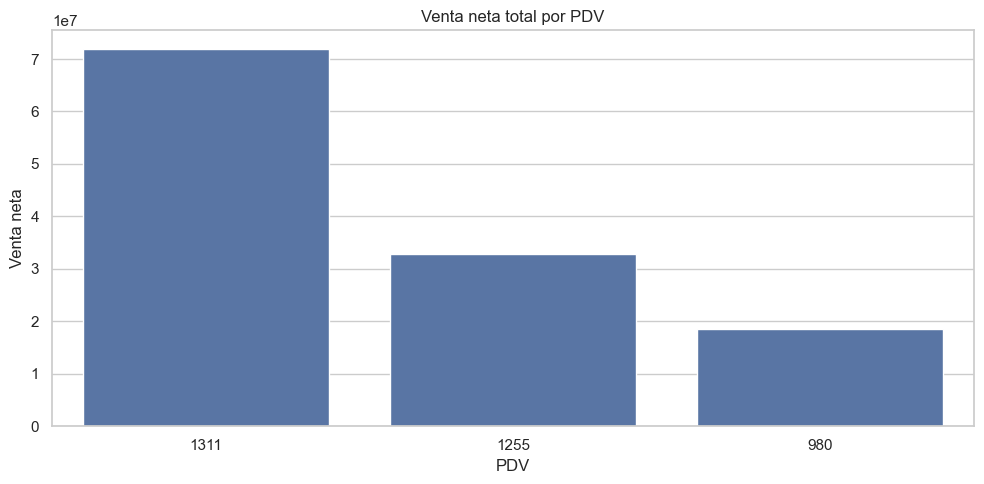

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\pdv\venta_neta_total_por_pdv.png


In [6]:
# ===============================
# Venta neta por PDV
# ===============================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=resumen_pdv,
    x="PDV",
    y="venta_neta",
    order=resumen_pdv["PDV"]
)

plt.title("Venta neta total por PDV")
plt.xlabel("PDV")
plt.ylabel("Venta neta")
plt.tight_layout()

output_fig = PDV_FIGURES_DIR / "venta_neta_total_por_pdv.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Venta neta total por punto de venta

La gráfica muestra la `VENTA_NETA` total acumulada por cada punto de venta durante todo el periodo analizado.

Se observa que el **PDV 1311** es claramente el punto de venta con mayor venta neta, superando ampliamente a los otros dos PDV. Su venta neta total está alrededor de **71,9 millones**, lo que confirma que es la tienda con mayor peso comercial dentro de la base.

El **PDV 1255** ocupa el segundo lugar, con una venta neta cercana a **32,7 millones**. Aunque su volumen es considerable, se encuentra bastante por debajo del PDV 1311.

Por su parte, el **PDV 980** presenta la menor venta neta total, con aproximadamente **18,6 millones**. Esto coincide con los análisis anteriores, donde este PDV también tenía menor número de tickets, productos y líneas de venta.

En conclusión, la venta neta está fuertemente concentrada en el PDV 1311. Esto indica que los puntos de venta no tienen el mismo peso dentro de la operación, por lo que el análisis debe realizarse también de forma segmentada por tienda. Para futuros modelos predictivos, `PDV` debe incluirse como una variable clave, ya que cada punto de venta presenta niveles de venta y dinámicas comerciales diferentes.

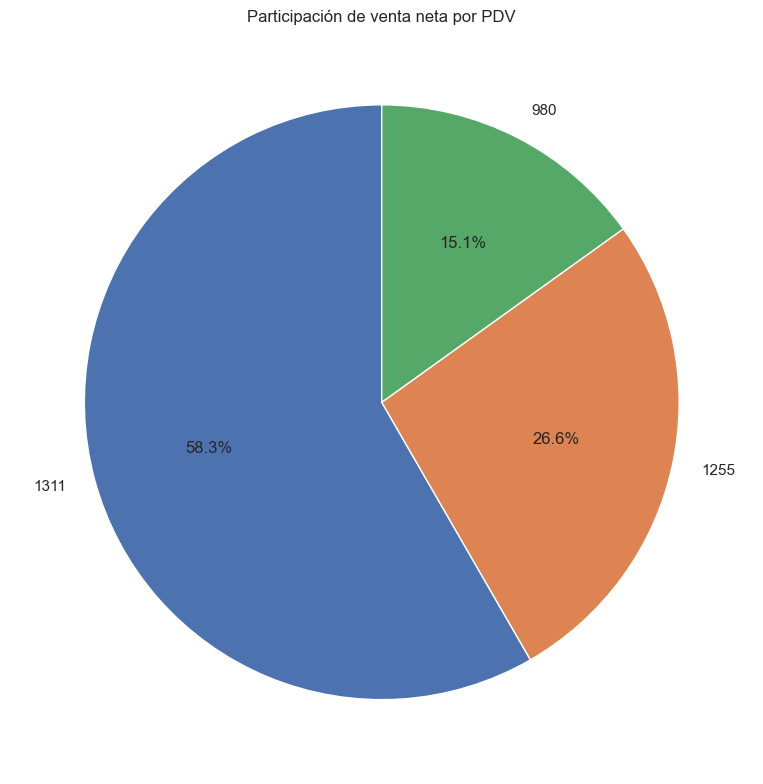

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\pdv\participacion_venta_neta_pdv.png


In [7]:
# ===============================
# Participación de venta neta por PDV
# ===============================

plt.figure(figsize=(8, 8))

plt.pie(
    resumen_pdv["venta_neta"],
    labels=resumen_pdv["PDV"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Participación de venta neta por PDV")
plt.tight_layout()

output_fig = PDV_FIGURES_DIR / "participacion_venta_neta_pdv.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Participación de venta neta por PDV

El gráfico de participación muestra cómo se distribuye la `VENTA_NETA` total entre los tres puntos de venta analizados.

El **PDV 1311** concentra la mayor proporción de la venta neta, con aproximadamente **58,3%** del total. Esto confirma que este punto de venta es el más importante dentro de la base y tiene un peso dominante en el comportamiento general de las ventas.

El **PDV 1255** representa cerca del **26,6%** de la venta neta total, ubicándose como el segundo punto de venta más relevante. Aunque su participación es considerable, se encuentra bastante por debajo del PDV 1311.

El **PDV 980** aporta aproximadamente el **15,1%** de la venta neta, siendo el punto de venta con menor participación dentro de la operación analizada.

En conclusión, la venta neta no está distribuida de forma equilibrada entre los PDV. El PDV 1311 explica más de la mitad de las ventas totales, por lo que cualquier análisis general de la base estará fuertemente influenciado por su comportamiento. Por esta razón, es importante analizar los resultados tanto de forma global como segmentada por punto de venta.

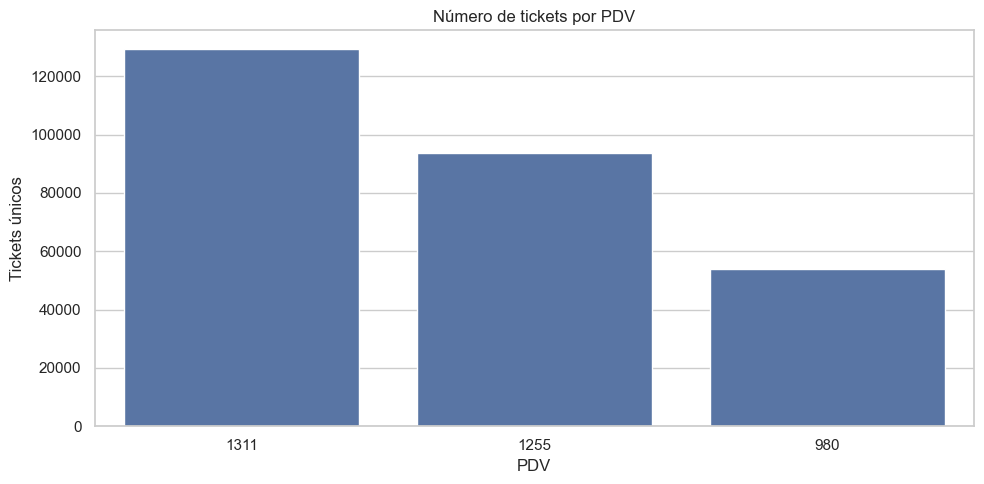

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\pdv\tickets_por_pdv.png


In [8]:
# ===============================
# Tickets por PDV
# ===============================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=resumen_pdv,
    x="PDV",
    y="tickets",
    order=resumen_pdv["PDV"]
)

plt.title("Número de tickets por PDV")
plt.xlabel("PDV")
plt.ylabel("Tickets únicos")
plt.tight_layout()

output_fig = PDV_FIGURES_DIR / "tickets_por_pdv.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Número de tickets por punto de venta

La gráfica muestra la cantidad de `tickets` únicos registrados por cada punto de venta durante todo el periodo analizado.

El **PDV 1311** presenta el mayor número de tickets, con aproximadamente **129.256 transacciones**, lo que confirma que es el punto de venta con mayor actividad comercial dentro de la base.

El **PDV 1255** ocupa el segundo lugar, con cerca de **93.693 tickets**, mientras que el **PDV 980** registra aproximadamente **54.040 tickets**, siendo el punto de venta con menor volumen transaccional.

Este comportamiento es consistente con el análisis de venta neta por PDV: la tienda que más tickets genera también es la que concentra mayor venta neta total. Sin embargo, el PDV 1311 no solo vende más por tener más transacciones, sino también porque presenta un ticket promedio neto más alto que los demás PDV.

En conclusión, el número de tickets confirma que la operación está concentrada principalmente en el PDV 1311. Por esta razón, en futuros análisis se debe evaluar el comportamiento de las ventas tanto por volumen de tickets como por valor promedio de compra.

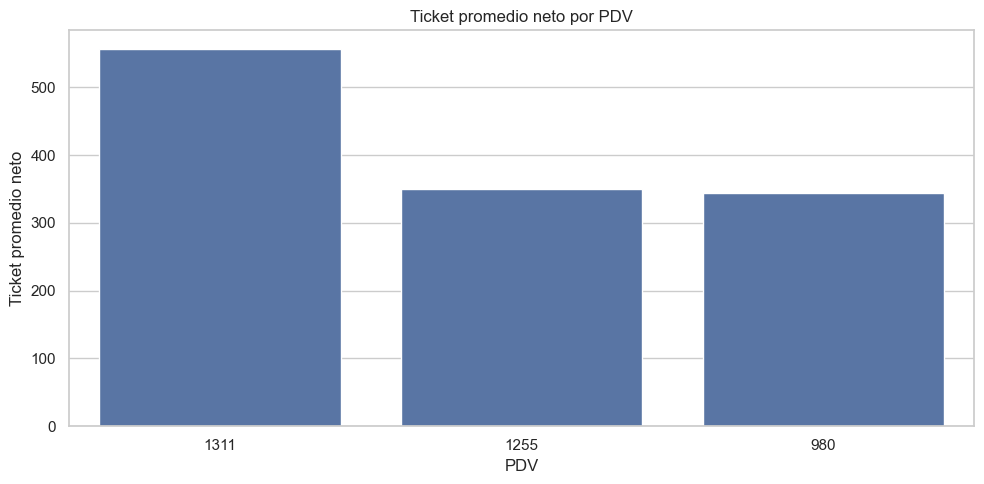

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\pdv\ticket_promedio_neto_por_pdv.png


In [9]:
# ===============================
# Ticket promedio neto por PDV
# ===============================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=resumen_pdv,
    x="PDV",
    y="ticket_promedio_neto",
    order=resumen_pdv["PDV"]
)

plt.title("Ticket promedio neto por PDV")
plt.xlabel("PDV")
plt.ylabel("Ticket promedio neto")
plt.tight_layout()

output_fig = PDV_FIGURES_DIR / "ticket_promedio_neto_por_pdv.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Ticket promedio neto por punto de venta

La gráfica compara el `ticket_promedio_neto` entre los tres puntos de venta.

Se observa que el **PDV 1311** tiene el ticket promedio neto más alto, con un valor cercano a **556**. Esto significa que, en promedio, cada transacción en este punto de venta genera más venta neta que en los otros PDV.

Los puntos de venta **1255** y **980** presentan tickets promedio netos más bajos y bastante similares entre sí, alrededor de **349** y **344**, respectivamente. Esto indica que, aunque ambos pertenecen al estrato 4, tienen un comportamiento de compra promedio parecido.

Este resultado ayuda a explicar por qué el PDV 1311 concentra una proporción tan alta de la venta neta total. No solo tiene más tickets, sino que además cada ticket tiene un mayor valor promedio.

En conclusión, el PDV 1311 presenta una ventaja tanto en volumen de transacciones como en valor promedio por compra. Por esta razón, el análisis por punto de venta debe considerar no solo la cantidad de tickets, sino también el ticket promedio neto.

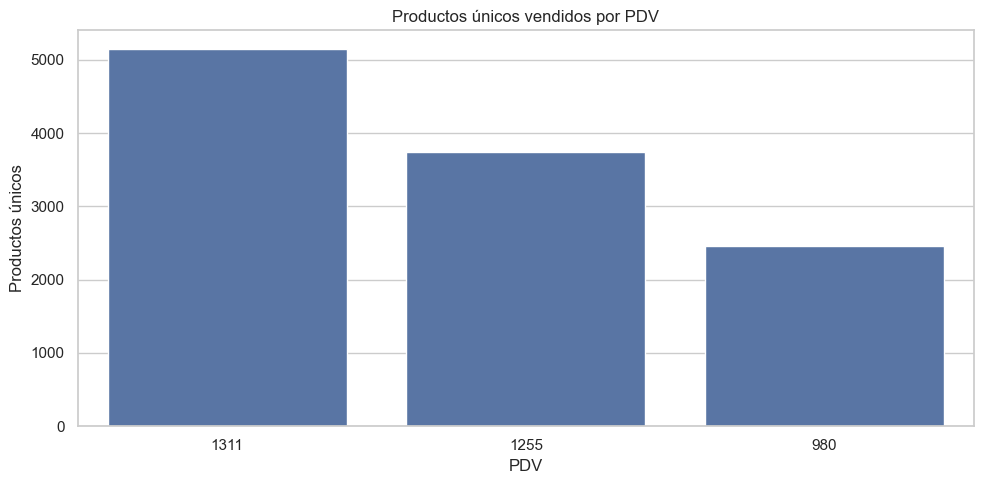

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\pdv\productos_unicos_por_pdv.png


In [10]:
# ===============================
# Productos únicos por PDV
# ===============================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=resumen_pdv,
    x="PDV",
    y="productos",
    order=resumen_pdv["PDV"]
)

plt.title("Productos únicos vendidos por PDV")
plt.xlabel("PDV")
plt.ylabel("Productos únicos")
plt.tight_layout()

output_fig = PDV_FIGURES_DIR / "productos_unicos_por_pdv.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Productos únicos vendidos por PDV

La gráfica muestra la cantidad de productos únicos vendidos en cada punto de venta durante todo el periodo analizado.

El **PDV 1311** presenta la mayor variedad de productos vendidos, con aproximadamente **5.142 productos únicos**. Esto confirma que, además de ser el punto de venta con mayor venta neta y mayor número de tickets, también es el que maneja el surtido más amplio dentro de la base.

El **PDV 1255** ocupa el segundo lugar, con cerca de **3.736 productos únicos**, mientras que el **PDV 980** registra alrededor de **2.461 productos únicos**, siendo el punto de venta con menor diversidad de productos.

Esta diferencia puede estar relacionada con el tamaño de la tienda, el perfil de los clientes, el estrato asociado, la disponibilidad de inventario o la estrategia comercial de cada PDV.

En conclusión, el PDV 1311 no solo lidera en ventas y tickets, sino también en variedad de productos vendidos. Por esta razón, el surtido o cantidad de productos activos por tienda puede ser una variable importante para explicar las diferencias de desempeño entre puntos de venta.

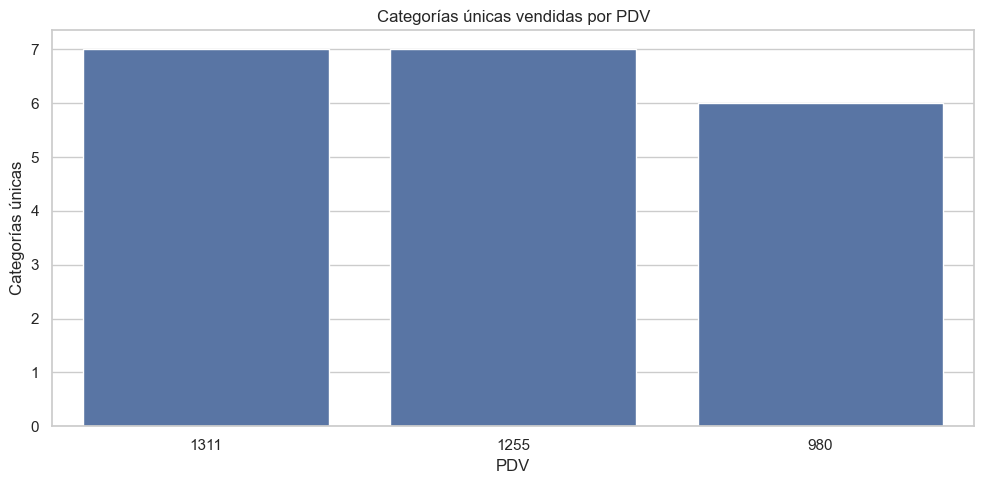

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\pdv\categorias_unicas_por_pdv.png


In [11]:
# ===============================
# Categorías únicas por PDV
# ===============================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=resumen_pdv,
    x="PDV",
    y="categorias",
    order=resumen_pdv["PDV"]
)

plt.title("Categorías únicas vendidas por PDV")
plt.xlabel("PDV")
plt.ylabel("Categorías únicas")
plt.tight_layout()

output_fig = PDV_FIGURES_DIR / "categorias_unicas_por_pdv.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Categorías únicas vendidas por PDV

La gráfica muestra la cantidad de categorías únicas vendidas en cada punto de venta durante el periodo analizado.

Los PDV **1311** y **1255** registran ventas en las **7 categorías** disponibles dentro de la base. Esto indica que ambos puntos de venta manejan una cobertura completa de categorías, al menos según la información entregada.

El **PDV 980** registra ventas en **6 categorías**, es decir, una categoría menos que los otros dos puntos de venta. Esto puede estar relacionado con menor surtido, menor tamaño de tienda, diferencias en inventario, disponibilidad de productos o una estrategia comercial distinta.

Aunque la diferencia parece pequeña, es importante porque el PDV 980 también presenta menor venta neta, menor número de tickets y menor cantidad de productos únicos. Por tanto, su menor cobertura de categorías puede estar asociada a su menor volumen comercial.

En conclusión, los puntos de venta no tienen exactamente la misma composición de categorías. Los PDV 1311 y 1255 muestran cobertura completa, mientras que el PDV 980 tiene una categoría menos. Esta diferencia debe considerarse en los análisis por tienda, especialmente al comparar ventas, surtido y desempeño por categoría.

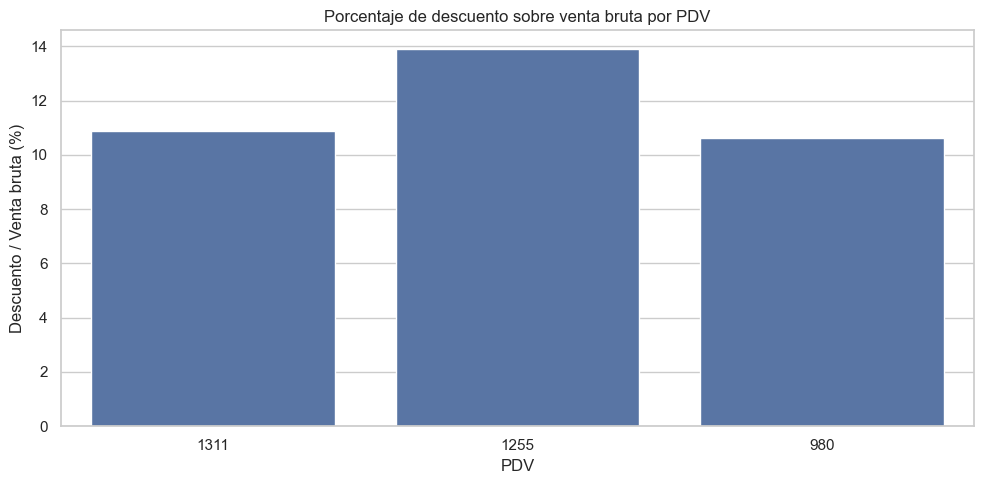

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\pdv\descuento_pct_por_pdv.png


In [12]:
# ===============================
# Porcentaje de descuento por PDV
# ===============================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=resumen_pdv,
    x="PDV",
    y="descuento_pct",
    order=resumen_pdv["PDV"]
)

plt.title("Porcentaje de descuento sobre venta bruta por PDV")
plt.xlabel("PDV")
plt.ylabel("Descuento / Venta bruta (%)")
plt.tight_layout()

output_fig = PDV_FIGURES_DIR / "descuento_pct_por_pdv.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Porcentaje de descuento sobre venta bruta por PDV

La gráfica compara el porcentaje de descuento aplicado sobre la venta bruta en cada punto de venta.

Se observa que el **PDV 1255** presenta el mayor porcentaje de descuento, con un valor cercano al **13,89%**. Esto indica que, proporcionalmente, este punto de venta aplica más descuentos sobre sus ventas brutas que los demás PDV.

El **PDV 1311** registra un descuento aproximado de **10,88%**, mientras que el **PDV 980** presenta un valor cercano al **10,63%**. Ambos tienen niveles de descuento similares y menores que el PDV 1255.

Este resultado es interesante porque el PDV 1311 es el que más vende en términos absolutos, pero no es el que tiene mayor presión de descuentos. En cambio, el PDV 1255 tiene menor venta neta total, pero mayor porcentaje de descuento relativo.

En conclusión, la estrategia promocional o de descuentos parece variar entre puntos de venta. El PDV 1255 muestra mayor intensidad relativa de descuentos, por lo que conviene analizar si esto está asociado a categorías específicas, productos, promociones o comportamiento de clientes.

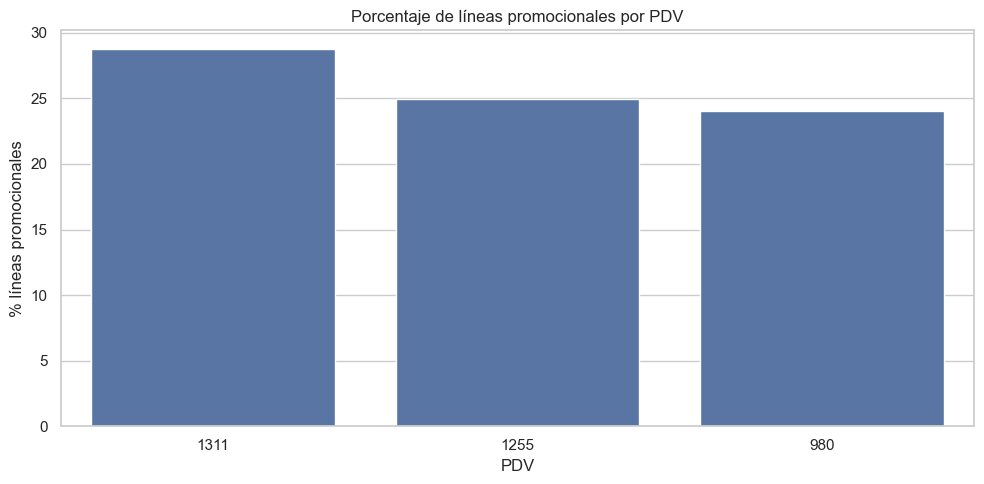

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\pdv\promo_pct_lineas_por_pdv.png


In [13]:
# ===============================
# Porcentaje de líneas promocionales por PDV
# ===============================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=resumen_pdv,
    x="PDV",
    y="promo_pct_lineas",
    order=resumen_pdv["PDV"]
)

plt.title("Porcentaje de líneas promocionales por PDV")
plt.xlabel("PDV")
plt.ylabel("% líneas promocionales")
plt.tight_layout()

output_fig = PDV_FIGURES_DIR / "promo_pct_lineas_por_pdv.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Porcentaje de líneas promocionales por PDV

La gráfica compara el porcentaje de líneas promocionales en cada punto de venta.

Se observa que el **PDV 1311** presenta el mayor porcentaje de líneas promocionales, cercano al **28,74%**. Esto indica que, además de ser el punto de venta con mayor venta neta, mayor número de tickets y mayor variedad de productos, también es el que tiene mayor participación relativa de líneas asociadas a promociones.

El **PDV 1255** ocupa el segundo lugar, con aproximadamente **24,98%** de líneas promocionales, mientras que el **PDV 980** registra cerca de **24,07%**. Ambos tienen una proporción promocional bastante similar.

Este resultado muestra que la actividad promocional existe en los tres puntos de venta, pero es más intensa en el PDV 1311. Sin embargo, al comparar con el porcentaje de descuento sobre venta bruta, se observa que el PDV 1255 tiene mayor descuento relativo, aunque no necesariamente mayor proporción de líneas promocionales.

En conclusión, las promociones no se comportan igual en todos los PDV. El PDV 1311 tiene más líneas promocionales, mientras que el PDV 1255 parece aplicar descuentos relativamente más fuertes. Por eso conviene analizar promociones considerando tanto la cantidad de líneas promocionales como el monto de descuento aplicado.

In [14]:
# ===============================
# Agregación mensual por PDV
# ===============================

ventas_mensuales_pdv = (
    df.groupby(["ANIO", "MES", "PDV", "Estrato"])
    .agg(
        filas=("NroReg", "count"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        tickets=("TICKET_ID", "nunique"),
        productos=("PLU_SAP", "nunique"),
        lineas_promo=("PROMO_FLAG", "sum")
    )
    .reset_index()
)

ventas_mensuales_pdv["FECHA_MES"] = pd.to_datetime(
    ventas_mensuales_pdv["ANIO"].astype(str) + "-" +
    ventas_mensuales_pdv["MES"].astype(str) + "-01"
)

ventas_mensuales_pdv["ticket_promedio_neto"] = np.where(
    ventas_mensuales_pdv["tickets"] > 0,
    ventas_mensuales_pdv["venta_neta"] / ventas_mensuales_pdv["tickets"],
    np.nan
)

ventas_mensuales_pdv["descuento_pct"] = np.where(
    ventas_mensuales_pdv["venta_bruta"] > 0,
    ventas_mensuales_pdv["descuento"] / ventas_mensuales_pdv["venta_bruta"] * 100,
    np.nan
)

ventas_mensuales_pdv["promo_pct_lineas"] = np.where(
    ventas_mensuales_pdv["filas"] > 0,
    ventas_mensuales_pdv["lineas_promo"] / ventas_mensuales_pdv["filas"] * 100,
    np.nan
)

ventas_mensuales_pdv = ventas_mensuales_pdv.sort_values(["PDV", "FECHA_MES"])

ventas_mensuales_pdv.head()

,ANIO,MES,PDV,Estrato,filas,venta_bruta,descuento,venta_neta,unidades,tickets,productos,lineas_promo,FECHA_MES,ticket_promedio_neto,descuento_pct,promo_pct_lineas
0,2023,1,1255,4,7059,"1,911,532.00","239,967.00","1,671,565.00","7,462.65",4783,1721,1960,2023-01-01,349.48,12.55,27.77
3,2023,2,1255,4,5905,"1,845,568.00","237,740.00","1,607,828.00","7,387.97",4185,1525,1689,2023-02-01,384.19,12.88,28.60
6,2023,3,1255,4,6000,"1,692,860.00","241,589.00","1,451,271.00","6,755.74",4070,1562,1826,2023-03-01,356.58,14.27,30.43
9,2023,4,1255,4,5428,"1,364,857.00","157,866.00","1,206,991.00","5,674.23",3757,1371,1454,2023-04-01,321.26,11.57,26.79
12,2023,5,1255,4,5204,"1,779,417.00","253,501.00","1,525,916.00","7,717.43",3674,1430,1414,2023-05-01,415.33,14.25,27.17


## Detalle mensual por PDV

La tabla muestra el comportamiento mensual de cada punto de venta (`PDV`), incluyendo métricas comerciales como `venta_bruta`, `descuento`, `venta_neta`, `unidades`, `tickets`, `productos`, `lineas_promo`, `ticket_promedio_neto`, `descuento_pct` y `promo_pct_lineas`.

En los registros mostrados se observa el desempeño del **PDV 1255** durante los primeros meses de 2023. La venta neta mensual inicia en **1.671.565** en enero, baja ligeramente en febrero a **1.607.828** y disminuye en marzo y abril, alcanzando **1.206.991** en abril. Luego, en mayo se observa una recuperación hasta **1.525.916**.

También se aprecia que el número de tickets y unidades sigue una tendencia similar a la venta neta. Por ejemplo, enero tiene **4.783 tickets** y abril baja a **3.757 tickets**, lo cual ayuda a explicar la reducción de ventas en ese mes.

El porcentaje de descuento se mantiene en niveles relativamente altos, entre aproximadamente **11,57%** y **14,27%**. Esto indica que el PDV 1255 tiene una actividad promocional importante durante estos meses.

El porcentaje de líneas promocionales también se mantiene cercano o superior al **26%**, llegando a **30,43%** en marzo. Esto sugiere que una proporción considerable de las ventas de este PDV está asociada a promociones u ofertas.

En conclusión, esta tabla permite analizar la evolución mensual de cada punto de venta de manera individual. Para el PDV 1255 se observa variación mensual en ventas, tickets y promociones, por lo que será importante comparar esta dinámica con los otros PDV para identificar diferencias de comportamiento entre tiendas.

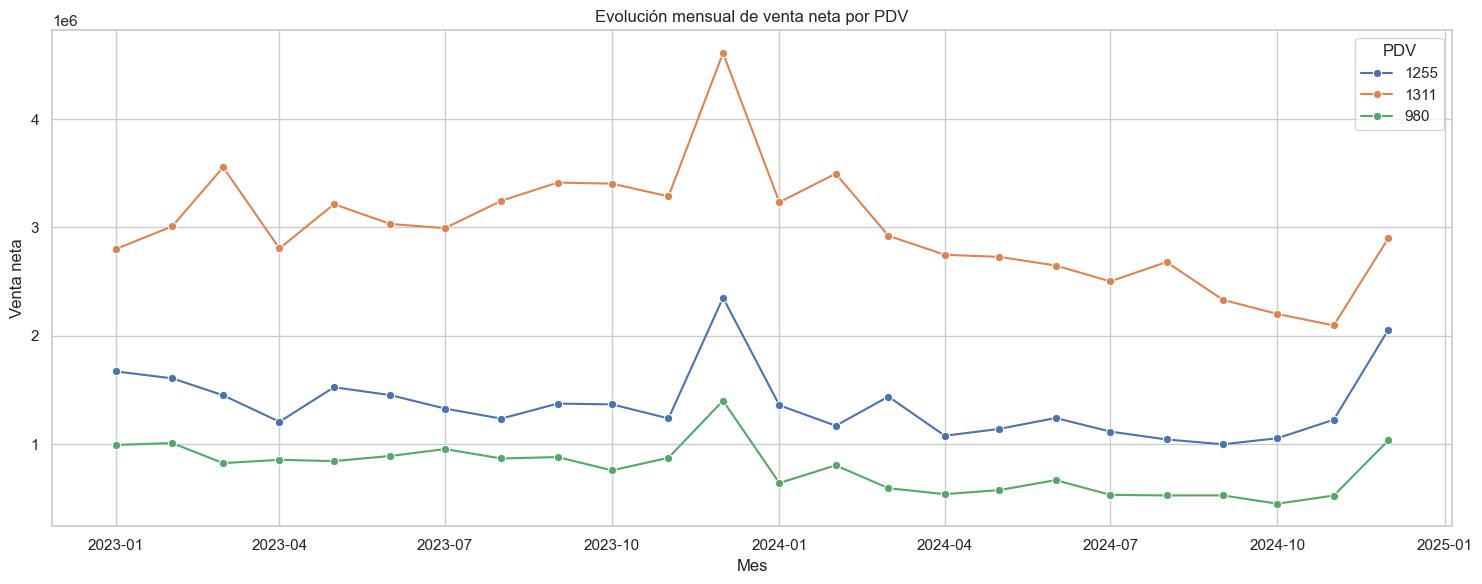

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\pdv\evolucion_mensual_venta_neta_pdv.png


In [15]:
# ===============================
# Evolución mensual de venta neta por PDV
# ===============================

plt.figure(figsize=(15, 6))

sns.lineplot(
    data=ventas_mensuales_pdv,
    x="FECHA_MES",
    y="venta_neta",
    hue="PDV",
    marker="o"
)

plt.title("Evolución mensual de venta neta por PDV")
plt.xlabel("Mes")
plt.ylabel("Venta neta")
plt.tight_layout()

output_fig = PDV_FIGURES_DIR / "evolucion_mensual_venta_neta_pdv.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Evolución mensual de venta neta por PDV

La gráfica muestra la evolución mensual de la `VENTA_NETA` para los tres puntos de venta durante el periodo 2023-2024.

Se observa que el **PDV 1311** mantiene de forma constante el mayor nivel de ventas mensuales. Durante todo el periodo se ubica por encima de los PDV 1255 y 980, lo que confirma su papel como el punto de venta principal dentro de la operación analizada.

El **PDV 1255** presenta el segundo mayor nivel de venta neta. Su comportamiento sigue una tendencia similar a la del PDV 1311, especialmente en los meses donde se observan picos de venta, como diciembre de 2023 y diciembre de 2024.

El **PDV 980** tiene la menor venta neta mensual durante casi todo el periodo. Sin embargo, también muestra los mismos patrones generales que los demás PDV: reducción durante buena parte de 2024 y recuperación hacia diciembre.

Un hallazgo importante es que los tres puntos de venta presentan un pico fuerte en **diciembre de 2023**, lo que confirma que el aumento de ventas en ese mes fue un fenómeno general y no exclusivo de una sola tienda. También se observa una recuperación en **diciembre de 2024**, aunque con valores inferiores a los de diciembre de 2023.

Durante 2024, los tres PDV muestran una disminución frente a los niveles de 2023, especialmente entre marzo y noviembre. Esto indica que la caída anual observada anteriormente afecta a toda la operación, aunque el impacto se mantiene más visible en los PDV de mayor volumen.

En conclusión, el análisis mensual por PDV confirma que el **PDV 1311 lidera claramente las ventas**, seguido por **1255** y luego **980**. Además, los tres puntos de venta comparten patrones temporales similares, por lo que `PDV`, `MES`, `ANIO` y variables estacionales como diciembre deben considerarse relevantes en futuros análisis y modelos predictivos.

In [16]:
# ===============================
# Resumen anual por PDV
# ===============================

resumen_anual_pdv = (
    df.groupby(["ANIO", "PDV", "Estrato"])
    .agg(
        filas=("NroReg", "count"),
        dias=("FECHA", "nunique"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        tickets=("TICKET_ID", "nunique"),
        productos=("PLU_SAP", "nunique"),
        lineas_promo=("PROMO_FLAG", "sum")
    )
    .reset_index()
)

resumen_anual_pdv["ticket_promedio_neto"] = np.where(
    resumen_anual_pdv["tickets"] > 0,
    resumen_anual_pdv["venta_neta"] / resumen_anual_pdv["tickets"],
    np.nan
)

resumen_anual_pdv["descuento_pct"] = np.where(
    resumen_anual_pdv["venta_bruta"] > 0,
    resumen_anual_pdv["descuento"] / resumen_anual_pdv["venta_bruta"] * 100,
    np.nan
)

resumen_anual_pdv["promo_pct_lineas"] = np.where(
    resumen_anual_pdv["filas"] > 0,
    resumen_anual_pdv["lineas_promo"] / resumen_anual_pdv["filas"] * 100,
    np.nan
)

resumen_anual_pdv

,ANIO,PDV,Estrato,filas,dias,venta_bruta,descuento,venta_neta,unidades,tickets,productos,lineas_promo,ticket_promedio_neto,descuento_pct,promo_pct_lineas
0,2023,1255,4,70719,365,"20,724,960.00","2,911,185.00","17,813,775.00","89,018.82",49355,3330,18650,360.93,14.05,26.37
1,2023,1311,6,114006,365,"44,833,107.00","5,462,279.00","39,370,828.00","132,873.63",72832,4565,36379,540.57,12.18,31.91
2,2023,980,4,43425,365,"12,563,555.00","1,402,030.00","11,161,525.00","56,892.31",30709,2064,10583,363.46,11.16,24.37
3,2024,1255,4,61908,366,"17,298,362.00","2,369,969.00","14,928,393.00","76,561.73",44338,2942,14479,336.70,13.70,23.39
4,2024,1311,6,87426,366,"35,805,307.00","3,314,940.00","32,490,367.00","99,864.97",56424,4052,21508,575.83,9.26,24.60
5,2024,980,4,32276,366,"8,237,207.00","809,733.00","7,427,474.00","39,761.77",23331,1893,7640,318.35,9.83,23.67


## Comparación anual por PDV

La tabla compara el desempeño de cada punto de venta entre **2023** y **2024**, permitiendo observar si la caída general de ventas se distribuye de manera similar entre las tiendas.

En los tres PDV se observa una disminución de la `VENTA_NETA` en 2024 frente a 2023. El **PDV 1311** sigue siendo el punto de venta líder en ambos años, con **39.370.828** en 2023 y **32.490.367** en 2024. Aunque disminuye, mantiene una diferencia amplia frente a los demás PDV.

El **PDV 1255** también reduce su venta neta, pasando de **17.813.775** en 2023 a **14.928.393** en 2024. Además, presenta una caída en filas, tickets, productos, unidades y líneas promocionales, lo que indica una menor actividad comercial general.

El **PDV 980** muestra una reducción importante, pasando de **11.161.525** en 2023 a **7.427.474** en 2024. Este PDV ya era el de menor volumen en 2023 y continúa siendo el de menor venta neta en 2024.

Un punto interesante es que el `ticket_promedio_neto` del **PDV 1311** aumenta en 2024, pasando de **540,57** a **575,83**. Esto sugiere que, aunque hubo menos tickets y menos unidades, el valor promedio por ticket fue mayor. En cambio, los PDV **1255** y **980** presentan una disminución en su ticket promedio neto.

También se observa una reducción en el porcentaje de líneas promocionales en los tres PDV. El caso más marcado es el PDV 1311, que pasa de **31,91%** en 2023 a **24,60%** en 2024. Esto puede estar relacionado con la menor actividad promocional observada durante 2024.

En conclusión, la caída de ventas de 2024 no se concentra en un solo punto de venta, sino que afecta a los tres PDV. Sin embargo, el PDV 1311 mantiene su liderazgo comercial, mientras que el PDV 980 continúa siendo el de menor volumen y el que requiere mayor revisión por su menor participación en ventas.

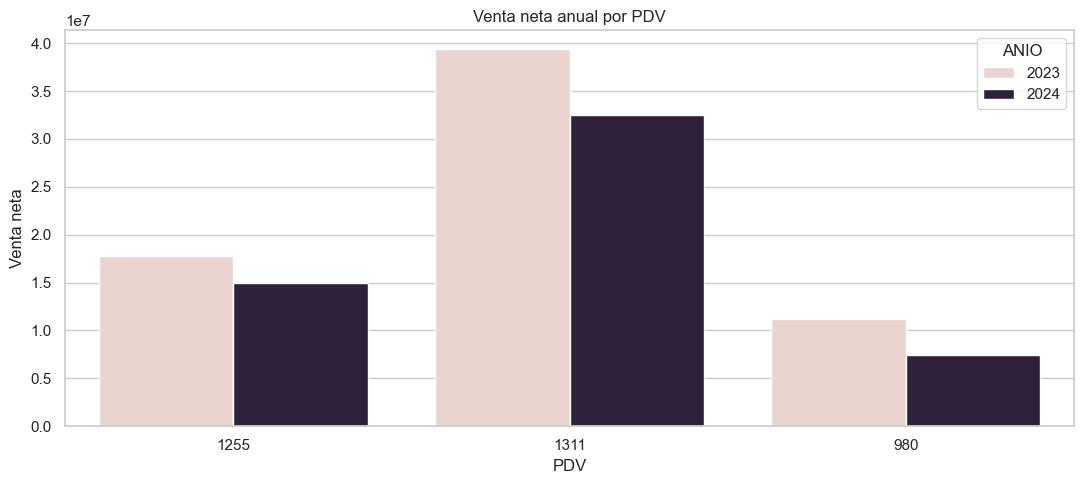

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\pdv\venta_neta_anual_por_pdv.png


In [17]:
# ===============================
# Venta neta anual por PDV
# ===============================

plt.figure(figsize=(11, 5))

sns.barplot(
    data=resumen_anual_pdv,
    x="PDV",
    y="venta_neta",
    hue="ANIO"
)

plt.title("Venta neta anual por PDV")
plt.xlabel("PDV")
plt.ylabel("Venta neta")
plt.tight_layout()

output_fig = PDV_FIGURES_DIR / "venta_neta_anual_por_pdv.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Venta neta anual por PDV

La gráfica compara la `VENTA_NETA` anual de cada punto de venta entre **2023** y **2024**.

Se observa que en los tres PDV la venta neta fue mayor en **2023** que en **2024**, lo que confirma visualmente la caída general de ventas identificada en las tablas anteriores.

El **PDV 1311** mantiene el liderazgo en ambos años. En 2023 registra la mayor venta neta de todos los puntos de venta y, aunque disminuye en 2024, sigue estando muy por encima de los PDV 1255 y 980. Esto confirma que es el punto de venta con mayor peso comercial dentro de la operación.

El **PDV 1255** ocupa el segundo lugar en ambos años. Su venta neta baja en 2024 frente a 2023, pero conserva una participación importante dentro del total.

El **PDV 980** presenta la menor venta neta anual en los dos años analizados y también muestra una reducción clara en 2024. Esto coincide con los análisis previos, donde este PDV registraba menor volumen de tickets, menor variedad de productos y menor participación en la venta total.

En conclusión, la caída de ventas en 2024 se observa en todos los puntos de venta, no solo en uno específico. Sin embargo, la estructura comercial se mantiene: el PDV 1311 lidera, seguido por 1255 y luego 980. Por esta razón, cualquier análisis o modelo predictivo debe considerar `PDV` como una variable clave.

In [18]:
# ===============================
# Variación anual 2024 vs 2023 por PDV
# ===============================

comparacion_anual_pdv = resumen_anual_pdv.pivot_table(
    index=["PDV", "Estrato"],
    columns="ANIO",
    values="venta_neta",
    aggfunc="sum"
).reset_index()

comparacion_anual_pdv.columns.name = None

if 2023 in comparacion_anual_pdv.columns and 2024 in comparacion_anual_pdv.columns:
    comparacion_anual_pdv["variacion_abs_2024_vs_2023"] = (
        comparacion_anual_pdv[2024] - comparacion_anual_pdv[2023]
    )
    
    comparacion_anual_pdv["variacion_pct_2024_vs_2023"] = np.where(
        comparacion_anual_pdv[2023] != 0,
        comparacion_anual_pdv["variacion_abs_2024_vs_2023"] / comparacion_anual_pdv[2023] * 100,
        np.nan
    )

comparacion_anual_pdv

,PDV,Estrato,2023,2024,variacion_abs_2024_vs_2023,variacion_pct_2024_vs_2023
0,1255,4,"17,813,775.00","14,928,393.00","-2,885,382.00",-16.20
1,1311,6,"39,370,828.00","32,490,367.00","-6,880,461.00",-17.48
2,980,4,"11,161,525.00","7,427,474.00","-3,734,051.00",-33.45


## Variación anual de venta neta por PDV: 2024 vs 2023

La tabla muestra la variación de la `VENTA_NETA` de cada punto de venta entre **2023** y **2024**, tanto en términos absolutos como porcentuales.

Se observa que los tres PDV presentan una disminución en 2024 frente a 2023. El **PDV 1311** tiene la mayor caída absoluta, con una reducción de **-6.880.461**, lo cual es esperable porque también es el punto de venta con mayor volumen de ventas. Sin embargo, su caída porcentual es de **-17,48%**, menor que la del PDV 980.

El **PDV 1255** presenta una reducción de **-2.885.382**, equivalente a una variación porcentual de **-16,20%**. Aunque también disminuye, es el PDV con la menor caída relativa entre los tres puntos de venta.

El **PDV 980** muestra la caída porcentual más fuerte, con **-33,45%**, pasando de **11.161.525** en 2023 a **7.427.474** en 2024. Esto indica que, aunque su caída absoluta es menor que la del PDV 1311, proporcionalmente fue el punto de venta más afectado.

En conclusión, la disminución de ventas en 2024 afectó a todos los puntos de venta, pero no con la misma intensidad. El PDV 1311 explica la mayor pérdida absoluta por su alto volumen, mientras que el PDV 980 presenta la mayor caída relativa. Esto sugiere que el análisis de la reducción de ventas debe hacerse de forma segmentada por PDV.

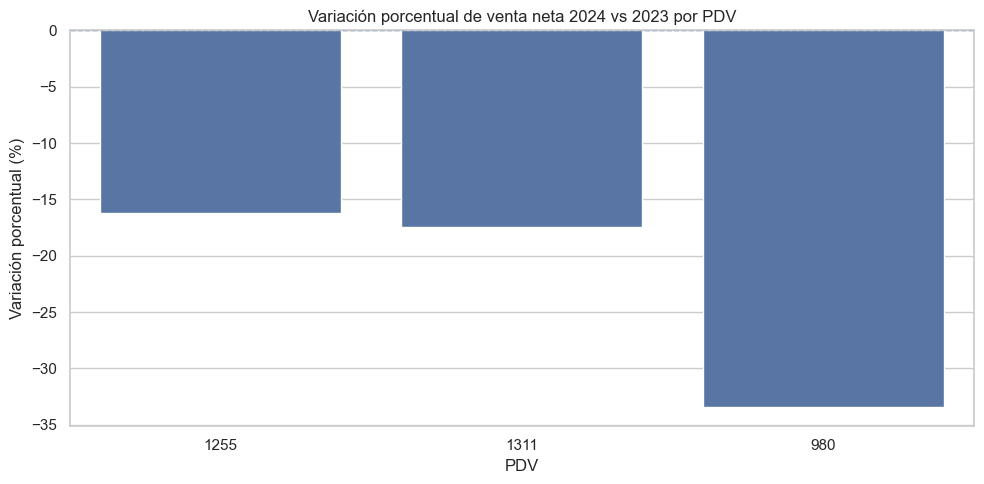

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\pdv\variacion_pct_2024_vs_2023_por_pdv.png


In [19]:
# ===============================
# Gráfico variación porcentual por PDV
# ===============================

if "variacion_pct_2024_vs_2023" in comparacion_anual_pdv.columns:
    plt.figure(figsize=(10, 5))

    sns.barplot(
        data=comparacion_anual_pdv,
        x="PDV",
        y="variacion_pct_2024_vs_2023"
    )

    plt.axhline(0, linestyle="--", linewidth=1)
    plt.title("Variación porcentual de venta neta 2024 vs 2023 por PDV")
    plt.xlabel("PDV")
    plt.ylabel("Variación porcentual (%)")
    plt.tight_layout()

    output_fig = PDV_FIGURES_DIR / "variacion_pct_2024_vs_2023_por_pdv.png"
    plt.savefig(output_fig, dpi=300, bbox_inches="tight")

    plt.show()

    print(f"Figura guardada en: {output_fig}")

## Variación porcentual de venta neta 2024 vs 2023 por PDV

La gráfica muestra la variación porcentual de la `VENTA_NETA` de cada punto de venta en **2024** frente a **2023**.

Se observa que los tres PDV presentan variaciones negativas, lo que confirma que la caída de ventas en 2024 fue generalizada y no estuvo concentrada únicamente en una tienda.

El **PDV 1255** presenta la menor disminución relativa, con una caída aproximada de **-16,20%**. Esto indica que, aunque vendió menos en 2024, fue el punto de venta con mejor resistencia frente al año anterior.

El **PDV 1311** registra una reducción cercana al **-17,48%**. A pesar de esta caída, sigue siendo el punto de venta con mayor volumen de venta neta total, por lo que su disminución tiene un impacto importante en el resultado global.

El **PDV 980** muestra la caída porcentual más fuerte, con aproximadamente **-33,45%**. Esto significa que fue el punto de venta más afectado proporcionalmente entre 2023 y 2024.

En conclusión, la gráfica confirma que todos los puntos de venta disminuyeron su venta neta en 2024. Sin embargo, el impacto fue más crítico en el PDV 980, mientras que los PDV 1255 y 1311 tuvieron caídas más moderadas. Este resultado refuerza la necesidad de analizar la reducción de ventas por tienda y no solamente de forma global.

In [20]:
# ===============================
# Resumen de categorías por PDV
# ===============================

resumen_categoria_pdv = (
    df.groupby(["PDV", "Estrato", "GRUCOM", "CATEG"])
    .agg(
        filas=("NroReg", "count"),
        tickets=("TICKET_ID", "nunique"),
        productos=("PLU_SAP", "nunique"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        lineas_promo=("PROMO_FLAG", "sum")
    )
    .reset_index()
)

total_pdv = resumen_categoria_pdv.groupby("PDV")["venta_neta"].transform("sum")

resumen_categoria_pdv["participacion_pdv_pct"] = np.where(
    total_pdv > 0,
    resumen_categoria_pdv["venta_neta"] / total_pdv * 100,
    np.nan
)

resumen_categoria_pdv = resumen_categoria_pdv.sort_values(
    ["PDV", "venta_neta"],
    ascending=[True, False]
)

resumen_categoria_pdv

,PDV,Estrato,GRUCOM,CATEG,filas,tickets,productos,venta_bruta,descuento,venta_neta,unidades,lineas_promo,participacion_pdv_pct
0,1255,4,10,04010,49983,39004,592,"18,457,962.00","2,619,584.00","15,838,378.00","92,368.00",10203,48.37
2,1255,4,11,08029,42548,32185,1089,"7,920,102.00","898,747.00","7,021,355.00","35,378.64",12016,21.44
3,1255,4,11,08042,17664,14214,931,"6,102,321.00","770,073.00","5,332,248.00","17,133.88",4896,16.29
4,1255,4,11,08061,18208,14628,600,"2,875,755.00","242,459.00","2,633,296.00","16,444.62",3989,8.04
5,1255,4,11,08062,3458,2756,371,"2,231,188.00","750,259.00","1,480,929.00","3,236.05",2024,4.52
6,1255,4,11,08067,576,203,151,"420,338.00",32.00,"420,306.00",800.36,1,1.28
1,1255,4,10,04019,190,189,2,"15,656.00",0.00,"15,656.00",219.00,0,0.05
7,1311,6,10,04010,70024,53286,943,"30,532,555.00","3,655,054.00","26,877,501.00","89,371.00",14031,37.40
10,1311,6,11,08042,30653,23024,1555,"22,593,341.00","1,977,521.00","20,615,820.00","38,661.35",10633,28.69
9,1311,6,11,08029,66017,45322,1199,"15,229,763.00","1,347,594.00","13,882,169.00","66,504.85",21590,19.32


## Composición de ventas por categoría dentro de cada PDV

La tabla muestra cómo se distribuye la venta neta de cada punto de venta (`PDV`) entre las diferentes categorías (`CATEG`) y grupos comerciales (`GRUCOM`).

En los tres puntos de venta, la categoría **04010** es la más importante. En el **PDV 1255**, esta categoría representa el **48,37%** de la venta neta del PDV; en el **PDV 1311**, representa el **37,40%**; y en el **PDV 980**, alcanza el **59,52%**. Esto indica que la categoría 04010 tiene un peso comercial dominante, especialmente en el PDV 980.

El **PDV 1311** muestra una composición más diversificada que los demás, ya que además de la categoría 04010, la categoría **08042** tiene una participación importante del **28,69%**, y la categoría **08029** representa el **19,32%**. Esto ayuda a explicar por qué este PDV tiene mayor venta neta total y mayor variedad de productos.

En el **PDV 1255**, después de la categoría 04010, las categorías más relevantes son **08029** con **21,44%** y **08042** con **16,29%**. Esto muestra que sus ventas también están concentradas en pocas categorías principales.

En el **PDV 980**, la concentración es todavía más fuerte: la categoría 04010 representa casi el 60% de la venta neta, seguida por **08029** con **27,24%**. Las demás categorías tienen participaciones mucho menores.

Las categorías **04019** y **08067** tienen participaciones muy bajas en todos los PDV. Esto indica que son categorías marginales dentro de la operación analizada y probablemente no tienen un impacto fuerte en la venta neta total.

En conclusión, la venta por PDV está fuertemente concentrada en pocas categorías, especialmente en `04010`. Sin embargo, el PDV 1311 presenta una estructura más diversificada, mientras que el PDV 980 depende más de una categoría principal. Para futuros análisis y modelos predictivos, será importante considerar la interacción entre `PDV`, `CATEG` y `GRUCOM`, ya que cada tienda tiene una composición comercial diferente.

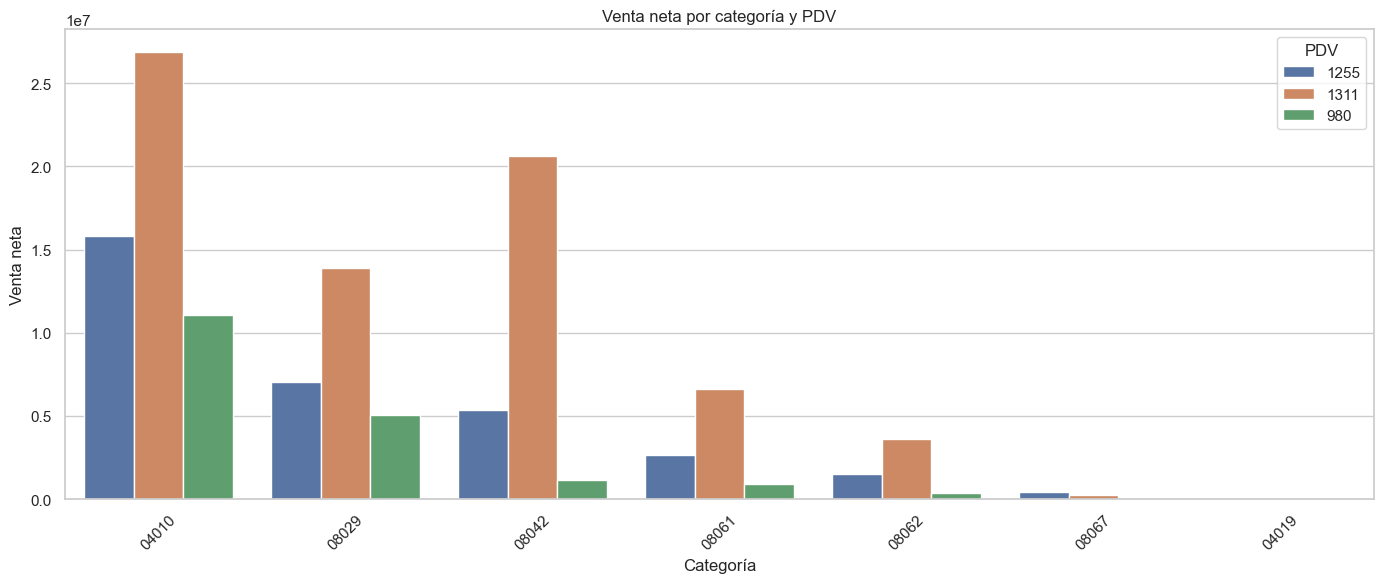

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\pdv\venta_neta_categoria_por_pdv.png


In [21]:
# ===============================
# Venta neta por categoría y PDV
# ===============================

plt.figure(figsize=(14, 6))

sns.barplot(
    data=resumen_categoria_pdv,
    x="CATEG",
    y="venta_neta",
    hue="PDV"
)

plt.title("Venta neta por categoría y PDV")
plt.xlabel("Categoría")
plt.ylabel("Venta neta")
plt.xticks(rotation=45)
plt.tight_layout()

output_fig = PDV_FIGURES_DIR / "venta_neta_categoria_por_pdv.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Venta neta por categoría y PDV

La gráfica compara la `VENTA_NETA` de cada categoría entre los tres puntos de venta. Se observa que la categoría **04010** es la de mayor venta neta en todos los PDV, confirmando que es la categoría principal de la base.

El **PDV 1311** lidera la venta neta en casi todas las categorías, especialmente en **04010**, **08042**, **08029**, **08061** y **08062**. Esto confirma que este punto de venta no solo vende más en total, sino que también tiene un desempeño superior en varias categorías.

En la categoría **04010**, los tres PDV tienen una participación importante, aunque el PDV 1311 presenta el mayor valor. Esta categoría parece ser el motor comercial más fuerte de toda la operación.

La categoría **08042** muestra una diferencia muy marcada: el PDV 1311 tiene una venta neta mucho mayor que los PDV 1255 y 980. Esto sugiere que esta categoría tiene una importancia particular en el PDV 1311.

Por otro lado, las categorías **08067** y **04019** presentan ventas netas muy bajas en comparación con las demás, por lo que tienen un peso marginal dentro de la operación.

En conclusión, la venta neta está concentrada principalmente en pocas categorías, especialmente `04010`, `08029` y `08042`. Además, el PDV 1311 domina la mayoría de las categorías, mientras que el PDV 980 tiene una participación más limitada. Para análisis posteriores, será importante estudiar la relación entre `PDV` y `CATEG`, ya que cada tienda tiene una composición de ventas diferente.

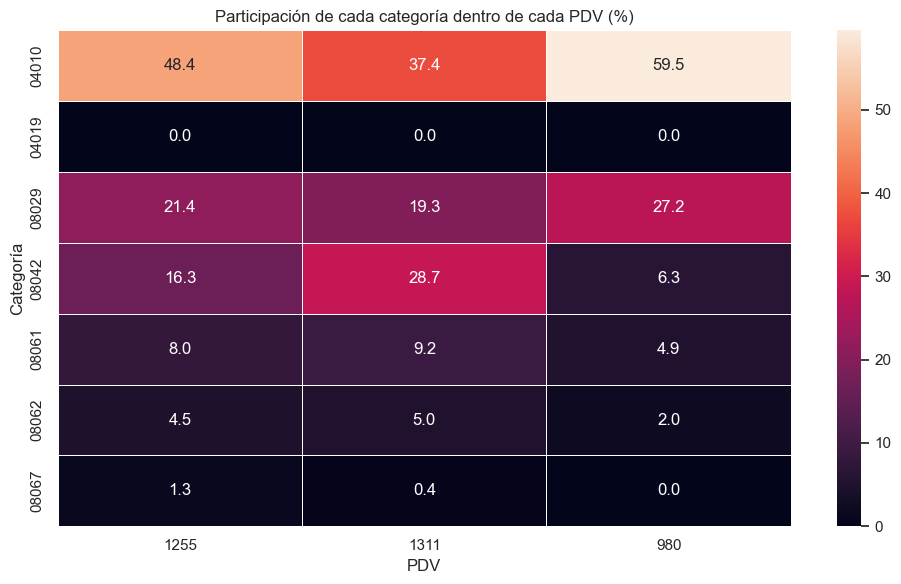

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\pdv\heatmap_participacion_categoria_pdv.png


In [22]:
# ===============================
# Heatmap participación de categorías por PDV
# ===============================

tabla_categoria_pdv = resumen_categoria_pdv.pivot_table(
    index="CATEG",
    columns="PDV",
    values="participacion_pdv_pct",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    tabla_categoria_pdv,
    annot=True,
    fmt=".1f",
    linewidths=0.5
)

plt.title("Participación de cada categoría dentro de cada PDV (%)")
plt.xlabel("PDV")
plt.ylabel("Categoría")
plt.tight_layout()

output_fig = PDV_FIGURES_DIR / "heatmap_participacion_categoria_pdv.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Participación de cada categoría dentro de cada PDV

El mapa de calor muestra qué porcentaje de la venta neta de cada punto de venta corresponde a cada categoría. Esta visualización permite entender la composición interna de ventas de cada tienda.

Se observa que la categoría **04010** es la más importante en los tres PDV. En el **PDV 1255** representa aproximadamente **48,4%** de la venta neta, en el **PDV 1311** representa **37,4%** y en el **PDV 980** alcanza **59,5%**. Esto indica que el PDV 980 depende en mayor medida de esta categoría.

La categoría **08029** también tiene una participación relevante en los tres puntos de venta, especialmente en el **PDV 980**, donde representa **27,2%** de la venta neta. En los PDV 1255 y 1311 su participación es cercana al **21,4%** y **19,3%**, respectivamente.

Un hallazgo importante es que el **PDV 1311** tiene una mayor participación de la categoría **08042**, con **28,7%**, mientras que en el PDV 1255 representa **16,3%** y en el PDV 980 apenas **6,3%**. Esto muestra que el PDV 1311 tiene una composición de ventas más diversificada y una dependencia menor de la categoría 04010.

Las categorías **08061** y **08062** tienen participaciones intermedias o bajas en todos los PDV, mientras que **08067** y **04019** tienen un peso muy reducido dentro de la venta neta total.

En conclusión, cada PDV tiene una estructura de ventas diferente. El PDV 980 depende principalmente de la categoría 04010, el PDV 1255 también está concentrado en 04010 pero con apoyo de 08029 y 08042, mientras que el PDV 1311 presenta una composición más equilibrada entre 04010, 08042 y 08029. Esta diferencia debe considerarse en análisis de surtido, promociones y futuros modelos predictivos.

In [23]:
# ===============================
# Top productos por PDV
# ===============================

productos_pdv = (
    df.groupby(["PDV", "PLU_SAP"])
    .agg(
        filas=("NroReg", "count"),
        dias=("FECHA", "nunique"),
        tickets=("TICKET_ID", "nunique"),
        categorias=("CATEG", "nunique"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        lineas_promo=("PROMO_FLAG", "sum")
    )
    .reset_index()
)

productos_pdv["rank_venta_pdv"] = productos_pdv.groupby("PDV")["venta_neta"].rank(
    ascending=False,
    method="dense"
)

top_10_productos_pdv = (
    productos_pdv[productos_pdv["rank_venta_pdv"] <= 10]
    .sort_values(["PDV", "rank_venta_pdv"])
)

top_10_productos_pdv

,PDV,PLU_SAP,filas,dias,tickets,categorias,venta_neta,unidades,lineas_promo,rank_venta_pdv
984,1255,1036266,2382,584,2205,1,"1,117,427.00","11,030.00",553,1.00
982,1255,1036253,1628,518,1556,1,"937,720.00","12,396.00",392,2.00
2963,1255,1331944,1309,438,1303,1,"903,668.00","2,054.00",27,3.00
1006,1255,1041245,371,235,365,1,"650,082.00","2,168.00",43,4.00
979,1255,1036246,2813,663,2742,1,"641,677.00","3,615.00",343,5.00
1007,1255,1041246,1091,516,1083,1,"560,448.00","3,235.00",49,6.00
3527,1255,1366966,551,239,543,1,"314,601.00","1,844.00",39,7.00
1455,1255,1156048,275,177,272,1,"265,555.00",636.00,14,8.00
3392,1255,1353916,340,216,340,1,"240,576.00",469.00,1,9.00
981,1255,1036252,1004,465,937,1,"227,233.00","1,464.00",186,10.00


## Top productos por venta neta dentro de cada PDV

La tabla muestra los productos con mayor `VENTA_NETA` dentro de cada punto de venta (`PDV`). Como la base no contiene nombres de productos, el análisis se realiza a partir del código `PLU_SAP`.

En el **PDV 1255**, el producto con mayor venta neta es el `PLU_SAP 1036266`, con **1.117.427**, seguido por `1036253` con **937.720** y `1331944` con **903.668**. Estos productos combinan alta frecuencia de aparición, muchos tickets y presencia durante una cantidad importante de días, por lo que parecen ser productos relevantes y constantes dentro de este punto de venta.

En el **PDV 1311**, el producto líder es `PLU_SAP 1036246`, con **900.756** de venta neta. Sin embargo, también aparecen productos como `1019790` y `1287167`, que tienen pocas filas y pocos tickets, pero una venta neta muy alta. Esto sugiere que pueden ser productos de mayor valor unitario o con compras puntuales de alto monto.

En el **PDV 980**, el producto con mayor venta neta es `PLU_SAP 1246431`, con **1.023.829**, a pesar de aparecer solo en **39 días**. Esto indica un comportamiento muy concentrado y posiblemente asociado a un producto de alto valor, una promoción puntual o una compra atípica. También destaca `PLU_SAP 1338873`, con muchas filas, muchos tickets y presencia en **655 días**, lo que sugiere un producto de venta frecuente.

También se observa que algunos productos aparecen entre los más importantes en más de un PDV, como `1036246`, `1036252`, `1025905` y `1023807`. Esto puede indicar productos transversales con buen desempeño en diferentes tiendas.

En conclusión, el ranking por producto muestra que cada PDV tiene una mezcla diferente entre productos de alta rotación y productos de alto valor. Para análisis posteriores, conviene estudiar estos productos líderes por separado, revisar su comportamiento temporal, su relación con promociones y su participación dentro de cada categoría.

In [24]:
# ===============================
# Tipo de promoción por PDV
# ===============================

promo_tipo_pdv = (
    df.groupby(["PDV", "TIPO_PROMO"])
    .agg(
        filas=("NroReg", "count"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        tickets=("TICKET_ID", "nunique")
    )
    .reset_index()
)

total_filas_pdv = promo_tipo_pdv.groupby("PDV")["filas"].transform("sum")
total_venta_pdv = promo_tipo_pdv.groupby("PDV")["venta_neta"].transform("sum")

promo_tipo_pdv["participacion_lineas_pdv_pct"] = np.where(
    total_filas_pdv > 0,
    promo_tipo_pdv["filas"] / total_filas_pdv * 100,
    np.nan
)

promo_tipo_pdv["participacion_venta_pdv_pct"] = np.where(
    total_venta_pdv > 0,
    promo_tipo_pdv["venta_neta"] / total_venta_pdv * 100,
    np.nan
)

promo_tipo_pdv

,PDV,TIPO_PROMO,filas,venta_bruta,descuento,venta_neta,unidades,tickets,participacion_lineas_pdv_pct,participacion_venta_pdv_pct
0,1255,Oferta y descuento,33039,"13,039,745.00","5,281,059.00","7,758,686.00","48,428.95",20768,24.91,23.70
1,1255,Sin promoción,99498,"24,981,335.00",0.00,"24,981,335.00","117,092.53",79471,75.02,76.30
2,1255,Solo descuento,5,628.00,156.00,472.00,4.08,5,0.00,0.00
3,1255,Solo oferta,85,"1,614.00",-61.00,"1,675.00",54.98,80,0.06,0.01
4,1311,Oferta y descuento,57690,"23,223,510.00","8,768,332.00","14,455,178.00","59,326.18",35551,28.64,20.12
5,1311,Sin promoción,143545,"57,398,415.00",0.00,"57,398,415.00","173,282.16",106239,71.26,79.87
6,1311,Solo descuento,86,"26,186.00","10,764.00","15,422.00",78.70,78,0.04,0.02
7,1311,Solo oferta,111,"-9,697.00","-1,877.00","-7,820.00",51.56,100,0.06,-0.01
8,980,Oferta y descuento,18173,"4,989,223.00","2,211,763.00","2,777,460.00","20,557.49",13743,24.01,14.94
9,980,Sin promoción,57478,"15,810,308.00",0.00,"15,810,308.00","76,049.23",45867,75.93,85.05


## Composición de ventas por tipo de promoción y PDV

La tabla muestra cómo se distribuyen las ventas de cada punto de venta según el tipo de promoción aplicado: `Sin promoción`, `Oferta y descuento`, `Solo descuento` y `Solo oferta`.

En los tres puntos de venta, la mayor parte de la venta neta proviene de registros **sin promoción**. En el **PDV 1255**, las líneas sin promoción representan el **75,02%** de las filas y el **76,30%** de la venta neta del PDV. En el **PDV 1311**, representan el **71,26%** de las líneas y el **79,87%** de la venta neta. En el **PDV 980**, representan el **75,93%** de las líneas y el **85,05%** de la venta neta.

La categoría `Oferta y descuento` también tiene un peso importante, especialmente en cantidad de líneas. En el **PDV 1311**, este tipo de promoción representa **57.690 filas**, equivalentes al **28,64%** de sus líneas, pero solo aporta el **20,12%** de la venta neta. Esto indica que, aunque hay muchas líneas promocionales, su aporte proporcional a la venta neta es menor que el de las líneas sin promoción.

En el **PDV 1255**, las líneas con `Oferta y descuento` representan el **24,91%** de las líneas y el **23,70%** de la venta neta. En el **PDV 980**, representan el **24,01%** de las líneas, pero solo el **14,94%** de la venta neta, lo que sugiere que las promociones en este PDV tienen menor aporte relativo al valor vendido.

Los tipos `Solo descuento` y `Solo oferta` tienen una participación muy baja en todos los PDV. Incluso en el PDV 1311 se observa que `Solo oferta` genera una venta neta negativa, lo cual puede estar relacionado con devoluciones, ajustes o registros especiales previamente identificados.

En conclusión, las ventas sin promoción son las que más aportan a la venta neta en todos los puntos de venta. Las promociones tienen una presencia importante en número de líneas, pero su peso en venta neta es menor, especialmente en el PDV 980. Por esta razón, es importante analizar las promociones no solo por cantidad de registros, sino también por su impacto real en la venta neta.

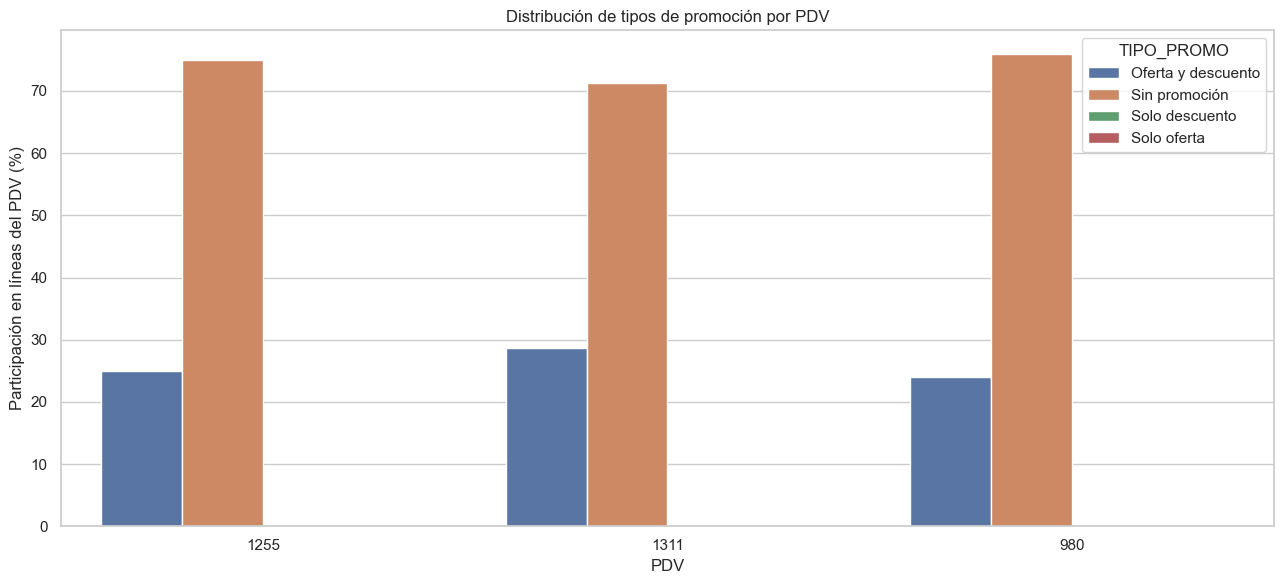

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\pdv\tipo_promocion_por_pdv.png


In [25]:
# ===============================
# Distribución de tipos de promoción por PDV
# ===============================

plt.figure(figsize=(13, 6))

sns.barplot(
    data=promo_tipo_pdv,
    x="PDV",
    y="participacion_lineas_pdv_pct",
    hue="TIPO_PROMO"
)

plt.title("Distribución de tipos de promoción por PDV")
plt.xlabel("PDV")
plt.ylabel("Participación en líneas del PDV (%)")
plt.tight_layout()

output_fig = PDV_FIGURES_DIR / "tipo_promocion_por_pdv.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Distribución de tipos de promoción por PDV

La gráfica muestra la distribución porcentual de los tipos de promoción dentro de cada punto de venta (`PDV`).

En los tres PDV predomina claramente la categoría **Sin promoción**, con participaciones superiores al **70%** de las líneas. Esto confirma que la mayor parte de los registros de venta no están asociados directamente a ofertas ni descuentos.

El segundo tipo más importante es **Oferta y descuento**. El **PDV 1311** presenta la mayor proporción de este tipo promocional, con un valor cercano al **28,6%**, seguido por el **PDV 1255** con aproximadamente **24,9%** y el **PDV 980** con cerca de **24,0%**.

Los tipos **Solo descuento** y **Solo oferta** tienen una presencia muy baja o prácticamente nula en la gráfica. Esto indica que, cuando existe promoción, normalmente aparece combinada como oferta y descuento, y no como una sola condición aislada.

En conclusión, la estructura promocional es bastante similar entre los tres puntos de venta: predominan las ventas sin promoción y, en segundo lugar, las líneas con oferta y descuento. Sin embargo, el PDV 1311 muestra una intensidad promocional ligeramente mayor, lo cual puede estar relacionado con su mayor volumen de ventas y mayor participación comercial dentro de la base.

In [26]:
# ===============================
# Ventas diarias por PDV
# ===============================

ventas_diarias_pdv = (
    df.groupby(["FECHA", "PDV"])
    .agg(
        filas=("NroReg", "count"),
        venta_bruta=("VENTA", "sum"),
        descuento=("DESCUENTO", "sum"),
        venta_neta=("VENTA_NETA", "sum"),
        unidades=("CANT", "sum"),
        tickets=("TICKET_ID", "nunique"),
        lineas_promo=("PROMO_FLAG", "sum")
    )
    .reset_index()
)

ventas_diarias_pdv["ticket_promedio_neto"] = np.where(
    ventas_diarias_pdv["tickets"] > 0,
    ventas_diarias_pdv["venta_neta"] / ventas_diarias_pdv["tickets"],
    np.nan
)

ventas_diarias_pdv.head()

,FECHA,PDV,filas,venta_bruta,descuento,venta_neta,unidades,tickets,lineas_promo,ticket_promedio_neto
0,2023-01-01,1255,97,"24,074.00",193.00,"23,881.00",143.07,72,4,331.68
1,2023-01-01,1311,60,"18,103.00",686.00,"17,417.00",71.43,38,6,458.34
2,2023-01-01,980,110,"27,423.00",570.00,"26,853.00",148.23,85,9,315.92
3,2023-01-02,1255,229,"61,903.00","1,028.00","60,875.00",250.44,162,8,375.77
4,2023-01-02,1311,120,"44,876.00",242.00,"44,634.00",150.72,79,10,564.99


## Construcción de la base diaria por PDV

La tabla muestra una agregación de la información a nivel de **fecha y punto de venta (`PDV`)**. En esta vista, cada fila representa el comportamiento diario de un PDV específico.

Se consolidan métricas como `filas`, `venta_bruta`, `descuento`, `venta_neta`, `unidades`, `tickets`, `lineas_promo` y `ticket_promedio_neto`. Esta estructura permite analizar la evolución diaria de cada tienda de manera separada.

En los primeros registros, correspondientes al **1 de enero de 2023**, se observa que los tres PDV tuvieron actividad comercial. El PDV **980** registra la mayor venta neta de ese día, con **26.853**, seguido por el PDV **1255** con **23.881** y el PDV **1311** con **17.417**.

También se observa que el `ticket_promedio_neto` varía entre puntos de venta. Por ejemplo, el 1 de enero de 2023 el PDV **1311** presenta un ticket promedio neto de **458,34**, superior al de los PDV 1255 y 980, aunque su venta neta total de ese día fue menor.

Para el **2 de enero de 2023**, la venta neta aumenta en los PDV mostrados, especialmente en el PDV **1255**, que alcanza **60.875**, y en el PDV **1311**, con **44.634**. Esto evidencia que el comportamiento comercial puede cambiar considerablemente de un día a otro.

En conclusión, esta base diaria por PDV es fundamental para analizar patrones específicos por tienda, comparar desempeño diario, identificar picos o caídas por punto de venta y preparar información útil para futuros modelos predictivos segmentados por `PDV`.

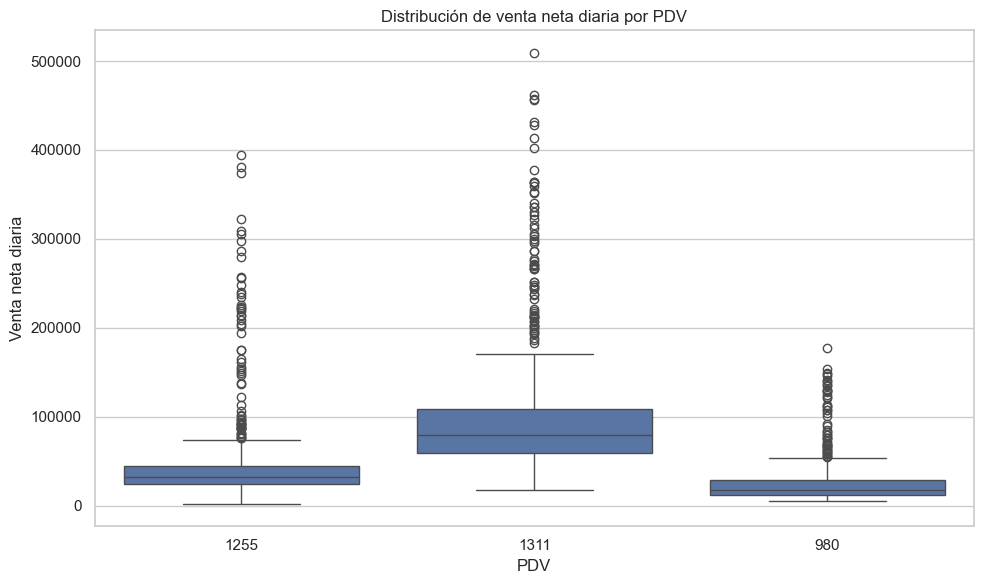

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\pdv\boxplot_venta_diaria_por_pdv.png


In [27]:
# ===============================
# Boxplot de venta diaria por PDV
# ===============================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=ventas_diarias_pdv,
    x="PDV",
    y="venta_neta"
)

plt.title("Distribución de venta neta diaria por PDV")
plt.xlabel("PDV")
plt.ylabel("Venta neta diaria")
plt.tight_layout()

output_fig = PDV_FIGURES_DIR / "boxplot_venta_diaria_por_pdv.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Distribución de venta neta diaria por PDV

El boxplot muestra la distribución de la `VENTA_NETA` diaria para cada punto de venta. Esta visualización permite comparar no solo el nivel promedio de ventas, sino también la dispersión, la variabilidad y la presencia de valores atípicos por tienda.

Se observa que el **PDV 1311** presenta la mayor mediana de venta neta diaria y también la mayor dispersión. Esto confirma que es el punto de venta con mayor nivel de ventas, pero también con mayor variabilidad entre días. Además, concentra varios valores atípicos altos, algunos superiores a **400.000** e incluso cercanos a **500.000**, lo que indica la presencia de días de venta extraordinaria.

El **PDV 1255** ocupa una posición intermedia. Su mediana diaria es menor que la del PDV 1311, pero superior a la del PDV 980. También presenta varios días atípicos altos, aunque con menor magnitud que los observados en el PDV 1311.

El **PDV 980** muestra la menor mediana de venta neta diaria y una distribución más concentrada en valores bajos. Aunque también presenta algunos valores atípicos, estos son menos frecuentes y de menor magnitud en comparación con los otros PDV.

En conclusión, la distribución diaria confirma que los puntos de venta tienen comportamientos comerciales diferentes. El PDV 1311 lidera en nivel de ventas y variabilidad, el PDV 1255 mantiene un desempeño intermedio y el PDV 980 presenta el menor volumen diario. Por esta razón, el análisis y los futuros modelos predictivos deben considerar `PDV` como una variable clave, ya que cada tienda tiene una escala y dinámica distinta.

In [28]:
# ===============================
# Calidad de datos por PDV
# ===============================

flags_calidad = [
    col for col in df.columns
    if col.startswith("FLAG_")
]

calidad_pdv = (
    df.groupby("PDV")
    .agg(
        filas=("NroReg", "count"),
        registros_especiales=("REGISTRO_ESPECIAL", "sum"),
        registros_validos_basicos=("REGISTRO_VALIDO_BASICO", "sum")
    )
    .reset_index()
)

for flag in flags_calidad:
    calidad_flag = df.groupby("PDV")[flag].sum().reset_index(name=flag)
    calidad_pdv = calidad_pdv.merge(calidad_flag, on="PDV", how="left")

calidad_pdv["registros_especiales_pct"] = np.where(
    calidad_pdv["filas"] > 0,
    calidad_pdv["registros_especiales"] / calidad_pdv["filas"] * 100,
    np.nan
)

calidad_pdv["registros_validos_basicos_pct"] = np.where(
    calidad_pdv["filas"] > 0,
    calidad_pdv["registros_validos_basicos"] / calidad_pdv["filas"] * 100,
    np.nan
)

calidad_pdv

,PDV,filas,registros_especiales,registros_validos_basicos,FLAG_FECHA_NULA,FLAG_CANT_NULA,FLAG_CANT_CERO,FLAG_CANT_NEGATIVA,FLAG_VENTA_NULA,FLAG_VENTA_CERO,FLAG_VENTA_NEGATIVA,FLAG_DESCUENTO_NULO,FLAG_DESCUENTO_CERO,FLAG_DESCUENTO_NEGATIVO,FLAG_DESCUENTO_MAYOR_VENTA,FLAG_VENTA_NETA_NULA,FLAG_VENTA_NETA_CERO,FLAG_VENTA_NETA_NEGATIVA,FLAG_PRECIO_UNITARIO_NETO_NULO,FLAG_PRECIO_UNITARIO_NETO_NEGATIVO,registros_especiales_pct,registros_validos_basicos_pct
0,1255,132627,4191,129092,0,82,767,63,0,1149,505,0,99581,2,2688,0,1422,2688,912,2589,3.16,97.33
1,1311,201432,6028,196513,0,68,982,55,0,1353,622,0,143646,10,3902,0,2059,3902,1105,3813,2.99,97.56
2,980,75701,3278,72932,0,30,573,15,0,968,636,0,57528,0,2209,0,1040,2209,618,2151,4.33,96.34


## Calidad de datos por PDV

La tabla resume las principales banderas de calidad por punto de venta (`PDV`) y permite comparar qué tiendas concentran más registros especiales o inconsistencias.

En términos absolutos, el **PDV 1311** presenta la mayor cantidad de registros especiales, con **6.028 casos**. Sin embargo, esto se explica en parte porque también es el punto de venta con más filas en la base. Al revisar el porcentaje, sus registros especiales representan solo **2,99%**, siendo el porcentaje más bajo entre los tres PDV.

El **PDV 1255** registra **4.191 casos especiales**, equivalentes al **3,16%** de sus registros. Su porcentaje de registros válidos básicos es de **97,33%**, lo cual indica una calidad general alta.

El **PDV 980** tiene menos registros especiales en términos absolutos, con **3.278 casos**, pero presenta el mayor porcentaje relativo, con **4,33%**. Además, tiene el menor porcentaje de registros válidos básicos, con **96,34%**. Esto sugiere que, proporcionalmente, es el punto de venta que requiere mayor revisión en calidad de datos.

Las banderas más relevantes en los tres PDV están relacionadas con `FLAG_DESCUENTO_MAYOR_VENTA`, `FLAG_VENTA_NETA_NEGATIVA` y `FLAG_PRECIO_UNITARIO_NETO_NEGATIVO`. Esto confirma que una parte importante de los registros especiales se explica por descuentos superiores al valor de la venta, lo que genera ventas netas negativas y precios unitarios netos inconsistentes.

También se observan casos de `FLAG_CANT_CERO`, `FLAG_VENTA_CERO`, `FLAG_VENTA_NEGATIVA` y `FLAG_CANT_NULA`, aunque con menor frecuencia. Estos registros pueden corresponder a anulaciones, devoluciones, ajustes operativos, errores de captura o movimientos comerciales especiales.

En conclusión, la calidad de datos es buena en los tres puntos de venta, con más del **96%** de registros válidos básicos en todos los casos. Sin embargo, el **PDV 980** debe revisarse con mayor atención por tener la mayor proporción de registros especiales, mientras que el **PDV 1311**, aunque tiene más casos absolutos, mantiene la mejor calidad relativa.

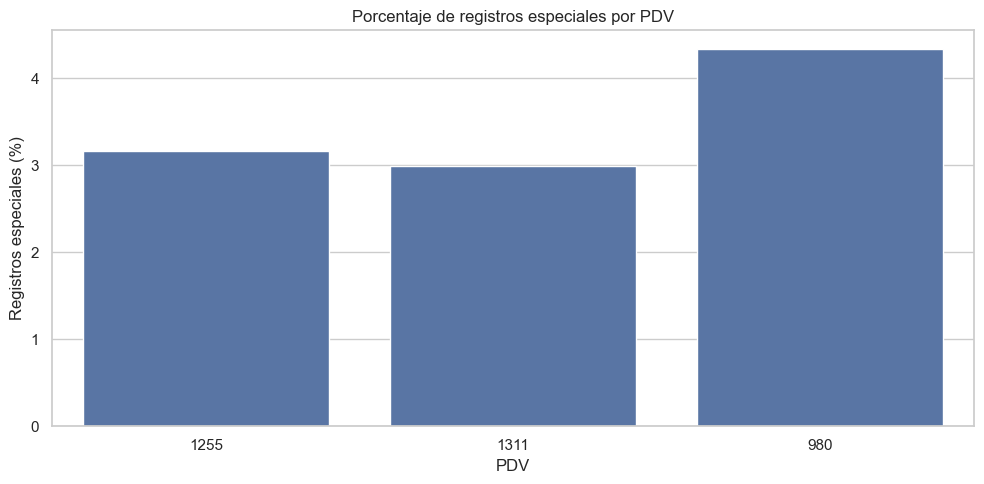

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\pdv\registros_especiales_pct_por_pdv.png


In [29]:
# ===============================
# Registros especiales por PDV
# ===============================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=calidad_pdv,
    x="PDV",
    y="registros_especiales_pct"
)

plt.title("Porcentaje de registros especiales por PDV")
plt.xlabel("PDV")
plt.ylabel("Registros especiales (%)")
plt.tight_layout()

output_fig = PDV_FIGURES_DIR / "registros_especiales_pct_por_pdv.png"
plt.savefig(output_fig, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {output_fig}")

## Porcentaje de registros especiales por PDV

La gráfica muestra el porcentaje de registros especiales en cada punto de venta (`PDV`).

Se observa que el **PDV 980** presenta el mayor porcentaje de registros especiales, con aproximadamente **4,33%**. Esto confirma que, aunque este punto de venta tiene menor volumen de registros, proporcionalmente concentra más casos que requieren revisión.

El **PDV 1255** tiene un porcentaje intermedio, cercano al **3,16%**, mientras que el **PDV 1311** presenta el menor porcentaje relativo, con aproximadamente **2,99%**. Esto indica que el PDV 1311, a pesar de tener la mayor cantidad absoluta de registros especiales, mantiene la mejor calidad relativa debido a su mayor volumen total de datos.

En conclusión, la calidad general de los tres PDV es aceptable, ya que los registros especiales representan una proporción baja en todos los casos. Sin embargo, el **PDV 980** debe revisarse con mayor atención porque presenta la mayor proporción de casos especiales dentro de sus registros.

In [30]:
# ===============================
# Ranking de PDV por indicadores clave
# ===============================

ranking_pdv = resumen_pdv[[
    "PDV",
    "Estrato",
    "venta_neta",
    "participacion_venta_neta_pct",
    "tickets",
    "participacion_tickets_pct",
    "ticket_promedio_neto",
    "productos",
    "categorias",
    "unidades",
    "descuento_pct",
    "promo_pct_lineas",
    "registros_especiales_pct"
]].copy()

ranking_pdv = ranking_pdv.sort_values("venta_neta", ascending=False)

ranking_pdv

,PDV,Estrato,venta_neta,participacion_venta_neta_pct,tickets,participacion_tickets_pct,ticket_promedio_neto,productos,categorias,unidades,descuento_pct,promo_pct_lineas,registros_especiales_pct
1,1311,6,"71,861,195.00",58.33,129256,46.66,555.96,5142,7,"232,738.60",10.88,28.74,2.99
0,1255,4,"32,742,168.00",26.58,93693,33.83,349.46,3736,7,"165,580.55",13.89,24.98,3.16
2,980,4,"18,588,999.00",15.09,54040,19.51,343.99,2461,6,"96,654.08",10.63,24.07,4.33


## Perfil comparativo de los puntos de venta

La tabla resume los principales indicadores comerciales y de calidad de datos para cada punto de venta (`PDV`).

El **PDV 1311** es el punto de venta más importante de la base. Concentra el **58,33%** de la venta neta total y el **46,66%** de los tickets. Además, tiene el mayor `ticket_promedio_neto`, con **555,96**, lo que indica que sus transacciones tienen un valor promedio más alto que las de los demás PDV. También es el punto con mayor variedad de productos, con **5.142 productos únicos**, y cobertura completa de **7 categorías**.

El **PDV 1255** ocupa el segundo lugar en participación de venta neta, con **26,58%**, y en participación de tickets, con **33,83%**. Su ticket promedio neto es menor que el del PDV 1311, con **349,46**. Un punto importante es que tiene el mayor porcentaje de descuento sobre venta bruta, con **13,89%**, lo que sugiere una mayor intensidad relativa de descuentos.

El **PDV 980** tiene la menor participación comercial, con **15,09%** de la venta neta y **19,51%** de los tickets. También presenta el menor número de productos únicos, con **2.461**, y solo registra ventas en **6 categorías**. Además, tiene el mayor porcentaje de registros especiales, con **4,33%**, por lo que requiere mayor atención en calidad de datos.

En términos promocionales, el **PDV 1311** presenta el mayor porcentaje de líneas promocionales, con **28,74%**, seguido por el PDV 1255 con **24,98%** y el PDV 980 con **24,07%**.

En conclusión, los tres puntos de venta tienen comportamientos distintos. El PDV 1311 lidera en ventas, tickets, ticket promedio, productos y promociones; el PDV 1255 tiene un desempeño intermedio y mayor descuento relativo; mientras que el PDV 980 muestra menor volumen comercial y mayor proporción de registros especiales. Por esta razón, el análisis y los futuros modelos predictivos deben considerar el `PDV` como una variable clave.

In [31]:
# ===============================
# Correlación de métricas diarias por PDV
# ===============================

metricas_correlacion_pdv = [
    "venta_bruta",
    "descuento",
    "venta_neta",
    "unidades",
    "tickets",
    "lineas_promo",
    "ticket_promedio_neto"
]

correlaciones_pdv = {}

for pdv in sorted(ventas_diarias_pdv["PDV"].unique()):
    temp = ventas_diarias_pdv[ventas_diarias_pdv["PDV"] == pdv]
    correlaciones_pdv[pdv] = temp[metricas_correlacion_pdv].corr()

correlaciones_pdv.keys()

dict_keys(['1255', '1311', '980'])

## Verificación de grupos o diccionario por PDV

La salida `dict_keys(['1255', '1311', '980'])` confirma que el objeto tipo diccionario fue creado correctamente y contiene una entrada para cada punto de venta disponible en la base.

Las llaves del diccionario corresponden a los tres PDV analizados: **1255**, **1311** y **980**. Esto indica que la información fue segmentada correctamente por tienda.

Este resultado es útil porque permite trabajar de forma individual con cada PDV, por ejemplo para consultar sus tablas, generar gráficos específicos, calcular métricas separadas o construir modelos independientes por punto de venta.

En conclusión, la estructura por diccionario quedó correctamente organizada y permite acceder fácilmente a los datos de cada tienda usando su código de PDV como llave.

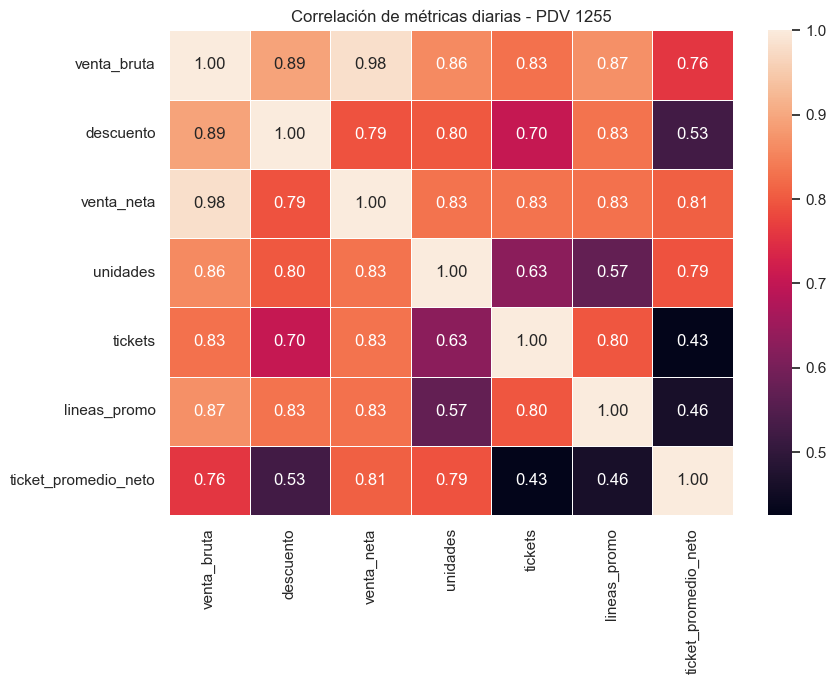

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\pdv\correlacion_metricas_diarias_pdv_1255.png


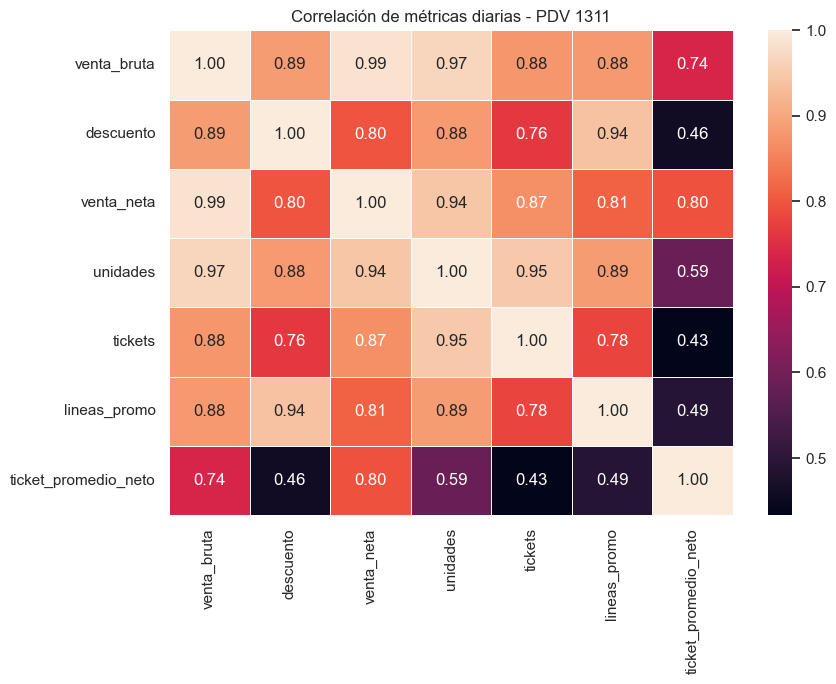

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\pdv\correlacion_metricas_diarias_pdv_1311.png


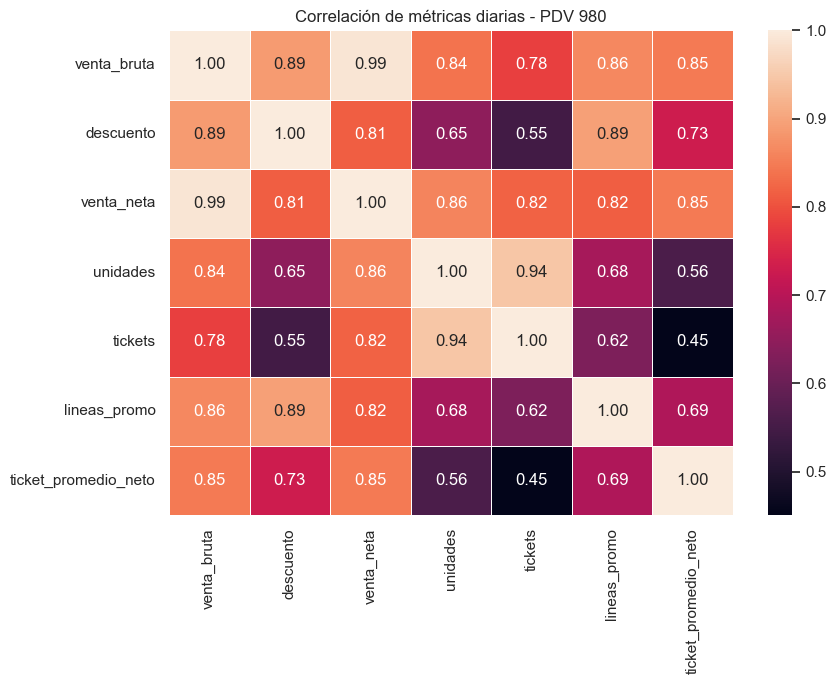

Figura guardada en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\figures\pdv\correlacion_metricas_diarias_pdv_980.png


In [32]:
# ===============================
# Heatmaps de correlación por PDV
# ===============================

for pdv, corr in correlaciones_pdv.items():
    plt.figure(figsize=(9, 7))
    
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        linewidths=0.5
    )
    
    plt.title(f"Correlación de métricas diarias - PDV {pdv}")
    plt.tight_layout()
    
    output_fig = PDV_FIGURES_DIR / f"correlacion_metricas_diarias_pdv_{pdv}.png"
    plt.savefig(output_fig, dpi=300, bbox_inches="tight")
    
    plt.show()
    
    print(f"Figura guardada en: {output_fig}")

## Correlación de métricas diarias por PDV

Las matrices muestran la correlación entre las principales métricas diarias para cada punto de venta: **1255**, **1311** y **980**. Este análisis permite identificar si las relaciones entre ventas, tickets, unidades, descuentos y promociones se comportan igual en todas las tiendas.

En los tres PDV se observa una correlación muy alta entre `venta_bruta` y `venta_neta`, cercana a **0,98 - 0,99**. Esto es esperable porque la venta neta se calcula a partir de la venta bruta descontando los descuentos aplicados.

También se observa una relación positiva entre `venta_neta`, `tickets`, `unidades` y `lineas_promo`. Esto indica que los días con mayor venta neta suelen estar asociados a mayor volumen de transacciones, más unidades vendidas y mayor actividad promocional.

En el **PDV 1255**, la `venta_neta` tiene correlaciones altas con `tickets`, `unidades` y `lineas_promo`, todas alrededor de **0,83**. Esto sugiere que la venta diaria de este PDV depende de una combinación equilibrada entre volumen de tickets, unidades vendidas y promociones.

En el **PDV 1311**, se observa una correlación muy fuerte entre `unidades` y `tickets`, cercana a **0,95**, y entre `venta_neta` y `unidades`, cercana a **0,94**. Esto indica que en este punto de venta el volumen de unidades vendidas tiene un peso muy importante para explicar la venta neta diaria.

En el **PDV 980**, el `ticket_promedio_neto` tiene una correlación alta con `venta_neta`, cercana a **0,85**, más fuerte que en los otros PDV. Esto sugiere que en el PDV 980 la venta diaria depende más del valor promedio por ticket que del número de tickets únicamente.

La relación entre `tickets` y `ticket_promedio_neto` es baja en los tres PDV, con valores cercanos a **0,43 - 0,45**. Esto indica que tener más tickets no necesariamente implica tener un mayor valor promedio por compra.

En conclusión, aunque los tres PDV comparten patrones generales similares, cada uno tiene dinámicas particulares. El PDV 1311 parece estar más asociado al volumen de unidades y tickets, el PDV 1255 muestra una relación balanceada entre volumen y promociones, y el PDV 980 parece depender más del ticket promedio neto. Por esta razón, en futuros modelos predictivos conviene considerar modelos segmentados por PDV o incluir interacciones entre `PDV`, `tickets`, `unidades`, `lineas_promo` y `ticket_promedio_neto`.

In [33]:
# ===============================
# Exportar tablas del análisis por PDV
# ===============================

output_excel = TABLES_DIR / "04_analisis_pdv.xlsx"

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    resumen_pdv.to_excel(writer, sheet_name="resumen_pdv", index=False)
    ventas_mensuales_pdv.to_excel(writer, sheet_name="mensual_pdv", index=False)
    resumen_anual_pdv.to_excel(writer, sheet_name="anual_pdv", index=False)
    comparacion_anual_pdv.to_excel(writer, sheet_name="comparacion_anual", index=False)
    resumen_categoria_pdv.to_excel(writer, sheet_name="categoria_pdv", index=False)
    productos_pdv.to_excel(writer, sheet_name="productos_pdv", index=False)
    top_10_productos_pdv.to_excel(writer, sheet_name="top_10_productos_pdv", index=False)
    promo_tipo_pdv.to_excel(writer, sheet_name="promo_tipo_pdv", index=False)
    ventas_diarias_pdv.to_excel(writer, sheet_name="ventas_diarias_pdv", index=False)
    calidad_pdv.to_excel(writer, sheet_name="calidad_pdv", index=False)
    ranking_pdv.to_excel(writer, sheet_name="ranking_pdv", index=False)

print(f"Archivo Excel exportado correctamente en: {output_excel}")

Archivo Excel exportado correctamente en: c:\Users\sergi\OneDrive\Desktop\Proyecto Olimpica\reports\tables\04_analisis_pdv.xlsx


## Conclusiones del análisis por PDV

A partir del análisis por punto de venta, se pueden establecer varias conclusiones preliminares:

1. Los PDV no tienen el mismo peso dentro de la base. Algunos puntos de venta concentran una mayor proporción de la venta neta, tickets, productos y unidades vendidas.

2. La participación de cada PDV en la venta neta permite identificar tiendas dominantes. Esto es importante porque un modelo predictivo podría verse sesgado hacia el comportamiento de los PDV con mayor volumen.

3. El ticket promedio neto permite comparar no solo cuánto vende cada tienda, sino también el valor promedio de compra por ticket.

4. La cantidad de productos y categorías vendidas por PDV permite identificar diferencias en amplitud comercial o surtido.

5. El análisis mensual por PDV muestra si las tiendas siguen una tendencia similar o si cada una tiene dinámicas propias.

6. La comparación 2024 vs 2023 por PDV permite revisar si la caída o crecimiento de ventas fue homogéneo en todas las tiendas o si estuvo concentrado en algunos puntos específicos.

7. La composición por categoría muestra qué categorías explican la venta dentro de cada PDV. Esto es importante porque dos tiendas pueden vender montos similares, pero con mezclas comerciales diferentes.

8. El análisis de promociones por PDV permite identificar si algunas tiendas dependen más de descuentos u ofertas para generar ventas.

9. La revisión de calidad de datos por PDV permite detectar si los registros especiales se concentran en algún punto de venta específico.

10. Para futuros modelos de predicción, el PDV debe ser considerado una variable explicativa clave, ya que las diferencias entre tiendas pueden influir significativamente en el comportamiento de las ventas.